In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
indeed_w1 = pd.read_csv("./new_data/Indeed_w1.csv", sep=",", skiprows=1)
indeed_w2 = pd.read_csv("./new_data/Indeed_w2.csv", sep=",", skiprows=1)
indeed_w3 = pd.read_csv("./new_data/Indeed_w3.csv", sep=",", skiprows=1)

stepstone_w1 = pd.read_csv("./new_data/Stepstone_w1.csv", sep=",", skiprows=1)
stepstone_w2 = pd.read_csv("./new_data/Stepstone_w2.csv", sep=",", skiprows=1)
stepstone_w3 = pd.read_csv("./new_data/Stepstone_w3.csv", sep=",", skiprows=1)

Bewerbung_w1 = pd.read_csv("./new_data/Bewerbung_w1.csv", sep=",", skiprows=1)
Bewerbung_w2 = pd.read_csv("./new_data/Bewerbung_w2.csv", sep=",", skiprows=1)
Bewerbung_w3 = pd.read_csv("./new_data/Bewerbung_w3.csv", sep=",", skiprows=1)

arbeitsamt_w1 = pd.read_csv("./new_data/Arbeitsamt_w1.csv", sep=",", skiprows=1)
arbeitsamt_w2 = pd.read_csv("./new_data/Arbeitsamt_w2.csv", sep=",", skiprows=1)
arbeitsamt_w3 = pd.read_csv("./new_data/Arbeitsamt_w3.csv", sep=",", skiprows=1)

jobbörse_w1 = pd.read_csv("./new_data/Jobbörse_w1.csv", sep=",", skiprows=1)
jobbörse_w2 = pd.read_csv("./new_data/Jobbörse_w2.csv", sep=",", skiprows=1)
jobbörse_w3 = pd.read_csv("./new_data/Jobbörse_w3.csv", sep=",", skiprows=1)




In [3]:
indeed_w1.columns = ["Date", "indeed"]
indeed_w2.columns = ["Date", "indeed"]
indeed_w3.columns = ["Date", "indeed"]

stepstone_w1.columns = ["Date", "stepstone"]
stepstone_w2.columns = ["Date", "stepstone"]
stepstone_w3.columns = ["Date", "stepstone"]

Bewerbung_w1.columns = ["Date","bewerbung"]
Bewerbung_w2.columns = ["Date","bewerbung"]
Bewerbung_w3.columns = ["Date","bewerbung"]

arbeitsamt_w1.columns = ["Date", "arbeitsamt"]
arbeitsamt_w2.columns = ["Date", "arbeitsamt"]
arbeitsamt_w3.columns = ["Date", "arbeitsamt"]

jobbörse_w1.columns = ["Date", "jobbörse"]
jobbörse_w2.columns = ["Date", "jobbörse"]
jobbörse_w3.columns = ["Date", "jobbörse"]






In [4]:
for df in [indeed_w1,indeed_w2,indeed_w3, stepstone_w1, stepstone_w2, stepstone_w3, Bewerbung_w1,Bewerbung_w2,Bewerbung_w3, arbeitsamt_w1,arbeitsamt_w2,arbeitsamt_w3, jobbörse_w1, jobbörse_w2, jobbörse_w3]:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    # convert value column to numeric (some lines may have non-numeric stuff)
    df[df.columns[1]] = pd.to_numeric(df[df.columns[1]], errors="coerce")

# The big stiching

In [5]:
import pandas as pd
import numpy as np

# --- Endpoints: weekly vs monthly
START = pd.Timestamp("2011-05-01")      # Sunday
END_WEEK = pd.Timestamp("2023-01-29")   # Sunday
END_MONTH = pd.Timestamp("2023-01-31")  # Month-end label for monthly data

def _prep(df, value_col):
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df[value_col] = pd.to_numeric(df[value_col], errors="coerce")
    df = df.dropna(subset=["Date", value_col]).set_index("Date").sort_index()
    return df

def _median_ratio(a, b):
    idx = a.index.intersection(b.index)
    x, y = a.loc[idx], b.loc[idx]
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if mask.sum() == 0:
        return 1.0
    return np.median((x[mask] / y[mask]).values)

def stitch_three(w1, w2, w3, value_col, final_name=None):
    W1 = _prep(w1, value_col)
    W2 = _prep(w2, value_col)
    W3 = _prep(w3, value_col)

    s21 = _median_ratio(W1[value_col], W2[value_col])
    W2r = W2 * s21

    s32 = _median_ratio(W2r[value_col], W3[value_col])
    W3r = W3 * s32

    out = pd.concat([
        W1,
        W2r.loc[~W2r.index.isin(W1.index)],
        W3r.loc[~W3r.index.isin(W1.index.union(W2r.index))]
    ]).sort_index()

    # Trim to weekly analysis window (Sundays)
    out = out.loc[(out.index >= START) & (out.index <= END_WEEK)].copy()

    if final_name is None:
        final_name = value_col
    out.columns = [final_name]
    out = out.reset_index().rename(columns={"index": "Date"})
    return out

# --- Build stitched weekly series
indeed     = stitch_three(indeed_w1,     indeed_w2,     indeed_w3,     "indeed",     "indeed")
stepstone  = stitch_three(stepstone_w1,  stepstone_w2,  stepstone_w3,  "stepstone",  "stepstone")
Bewerbung  = stitch_three(Bewerbung_w1,  Bewerbung_w2,  Bewerbung_w3,  "bewerbung",  "bewerbung")
arbeitsamt = stitch_three(arbeitsamt_w1, arbeitsamt_w2, arbeitsamt_w3, "arbeitsamt", "arbeitsamt")
jobbörse   = stitch_three(jobbörse_w1,   jobbörse_w2,   jobbörse_w3,   "jobbörse",   "jobbörse")

# --- Sanity (weekly Sunday grid)
for name, d in [("indeed", indeed), ("stepstone", stepstone), ("jobbörse", jobbörse), ("arbeitsamt", arbeitsamt), ("Bewerbung", Bewerbung)]:
    assert d["Date"].min() == START and d["Date"].max() == END_WEEK, f"{name} weekly range mismatch"
    assert (d["Date"].diff().dropna().dt.days == 7).all(), f"{name} not weekly by 7-day steps"

# --- Merge (weekly aligned)
df_week = (stepstone.merge(indeed,     on="Date", how="inner")
                   .merge(jobbörse,   on="Date", how="inner")
                   .merge(arbeitsamt, on="Date", how="inner")
                   .merge(Bewerbung,  on="Date", how="inner"))

# Optional: save weekly
# df_week.to_csv("./new_data/google_weekly_stitched_merged.csv", index=False)

# --- If you want MONTHLY (to align with unemployment at month-end labels)
df_month = (df_week.set_index("Date")
                    .resample("M").mean()
                    .reset_index())
# Ensure last label is 2023-01-31
assert df_month["Date"].max() == END_MONTH, "Monthly last date not 2023-01-31"

# Optional: save monthly
# df_month.to_csv("./new_data/google_monthly_stitched_merged.csv", index=False)


/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_33415/3039807760.py:73: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M").mean()


In [6]:
for name, d in [
    ("indeed", indeed),
    ("stepstone", stepstone),
    ("jobbörse", jobbörse),
    ("arbeitsamt", arbeitsamt),
    ("Bewerbung", Bewerbung)
]:
    print(f"\n=== {name.upper()} ===")
    print(f"Start: {d['Date'].min()} | End: {d['Date'].max()} | Rows: {len(d)}")
    gaps = d["Date"].diff().value_counts().head()
    print("Most common interval diffs:\n", gaps)
    missing = d["Date"].diff().dt.days.gt(8).sum()
    if missing:
        print(f"⚠️ Warning: {missing} gaps > 8 days detected")
    else:
        print("✅ No week gaps detected.")



=== INDEED ===
Start: 2011-05-01 00:00:00 | End: 2023-01-29 00:00:00 | Rows: 614
Most common interval diffs:
 Date
7 days    613
Name: count, dtype: int64
✅ No week gaps detected.

=== STEPSTONE ===
Start: 2011-05-01 00:00:00 | End: 2023-01-29 00:00:00 | Rows: 614
Most common interval diffs:
 Date
7 days    613
Name: count, dtype: int64
✅ No week gaps detected.

=== JOBBÖRSE ===
Start: 2011-05-01 00:00:00 | End: 2023-01-29 00:00:00 | Rows: 614
Most common interval diffs:
 Date
7 days    613
Name: count, dtype: int64
✅ No week gaps detected.

=== ARBEITSAMT ===
Start: 2011-05-01 00:00:00 | End: 2023-01-29 00:00:00 | Rows: 614
Most common interval diffs:
 Date
7 days    613
Name: count, dtype: int64
✅ No week gaps detected.

=== BEWERBUNG ===
Start: 2011-05-01 00:00:00 | End: 2023-01-29 00:00:00 | Rows: 614
Most common interval diffs:
 Date
7 days    613
Name: count, dtype: int64
✅ No week gaps detected.


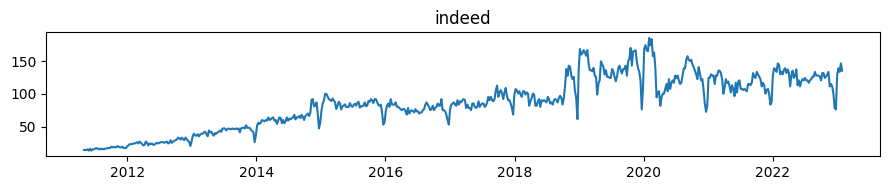

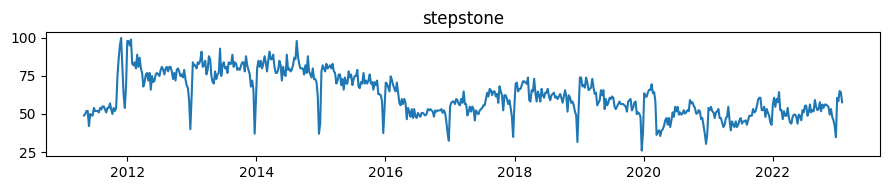

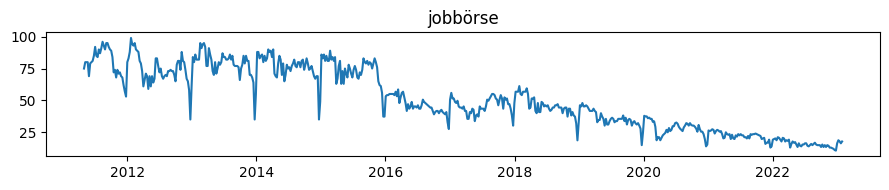

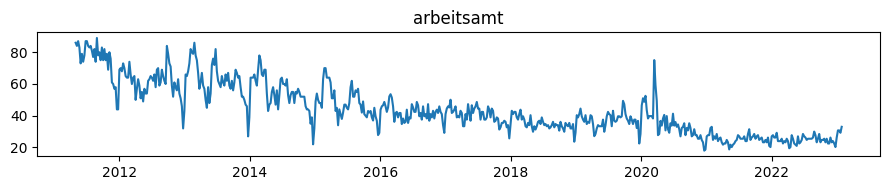

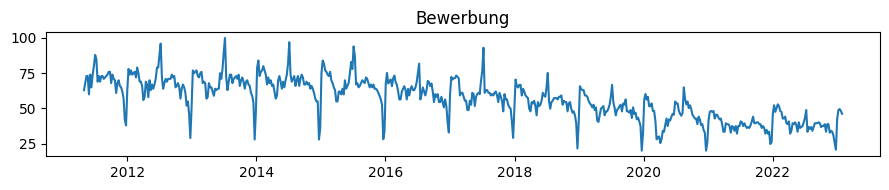

In [7]:
import matplotlib.pyplot as plt

for name, d in [
    ("indeed", indeed),
    ("stepstone", stepstone),
    ("jobbörse", jobbörse),
    ("arbeitsamt", arbeitsamt),
    ("Bewerbung", Bewerbung)
]:
    plt.figure(figsize=(9,2))
    plt.plot(d["Date"], d[d.columns[1]], label=name)
    plt.title(name)
    plt.tight_layout()
    plt.show()


In [9]:
# ==========================================================
#  BIWEEKLY AGGREGATION  (Zimmer-style W12 / W34prev design)
# ==========================================================
import pandas as pd

# df_week: weekly merged Google Trends (columns like ['stepstone','indeed','jobbörse','arbeitsamt','bewerbung'])
# Date column: weekly Sundays
wk = df_week.copy()
wk["Date"] = pd.to_datetime(wk["Date"])
wk = wk.set_index("Date").sort_index()

# --- Helper calendar columns
wk["year"]  = wk.index.year
wk["month"] = wk.index.month
wk["day"]   = wk.index.day

# --- W12(M): weeks from days 1–15 within month M (early-month activity)
w12 = (
    wk[wk["day"] <= 15]
    .groupby(pd.Grouper(freq="M"))[
        ["stepstone","indeed","jobbörse","arbeitsamt","bewerbung"]
    ].mean()
)
w12.columns = [c + "_W12" for c in w12.columns]

# --- W34(M−1): weeks from days >15 of month M−1 (late-month activity)
# Shift forward by one month to align them with month M
w34_prev = (
    wk[wk["day"] > 15]
    .groupby(pd.Grouper(freq="M"))[
        ["stepstone","indeed","jobbörse","arbeitsamt","bewerbung"]
    ].mean()
)
w34_prev = w34_prev.shift(1, freq="M")
w34_prev.columns = [c + "_W34prev" for c in w34_prev.columns]

# --- Combine W12 and W34prev into a biweekly feature panel aligned to month M
biweekly = pd.concat([w12, w34_prev], axis=1).sort_index()

# --- Trim to your analytical window (month-end timestamps)
biweekly = biweekly.loc["2011-05-31":"2023-01-31"]

print("✅ Biweekly feature panel created:")
print(biweekly.head())
print(biweekly.tail())
print("Shape:", biweekly.shape)


✅ Biweekly feature panel created:
            stepstone_W12  indeed_W12  jobbörse_W12  arbeitsamt_W12  \
Date                                                                  
2011-05-31      50.333333        14.0     78.333333       85.666667   
2011-06-30      49.500000        14.5     79.500000       76.500000   
2011-07-31      52.000000        16.5     88.500000       85.500000   
2011-08-31      54.000000        15.5     93.500000       79.500000   
2011-09-30      52.500000        16.5     95.000000       79.000000   

            bewerbung_W12  stepstone_W34prev  indeed_W34prev  \
Date                                                           
2011-05-31           68.0                NaN             NaN   
2011-06-30           69.5          47.000000       14.000000   
2011-07-31           86.5          51.500000       15.000000   
2011-08-31           73.0          52.333333       15.666667   
2011-09-30           73.5          54.000000       15.500000   

            jobbörs

/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_33415/356134121.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(pd.Grouper(freq="M"))[
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_33415/356134121.py:30: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(pd.Grouper(freq="M"))[
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_33415/356134121.py:34: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  w34_prev = w34_prev.shift(1, freq="M")


In [10]:
print("Start:", biweekly.index.min())
print("End:", biweekly.index.max())
print("Number of observations:", len(biweekly))
print(biweekly.index.freq)  # Should be M or ME

Start: 2011-05-31 00:00:00
End: 2023-01-31 00:00:00
Number of observations: 141
<MonthEnd>


In [12]:
data = pd.read_csv("unemployment_rate_germany_DE_only.csv", sep=',')
data_copy = data.copy()
data = data[(data["Date"]>= "2011-05-01") & (data["Date"] <= "2023-01-01")]
unemp = data 

In [13]:
unemp.columns = ["Date", "Unemp"]
unemp["Date"] = pd.to_datetime(unemp["Date"])
unemp = unemp.set_index("Date")
# align to month-end index
unemp.index = unemp.index.to_period("M").to_timestamp("M")
panel = biweekly.join(unemp, how="inner")
panel = panel.dropna()

In [14]:
panel

,stepstone_W12,indeed_W12,jobbörse_W12,arbeitsamt_W12,bewerbung_W12,stepstone_W34prev,indeed_W34prev,jobbörse_W34prev,arbeitsamt_W34prev,bewerbung_W34prev,Unemp
Date,,,,,,,,,,,
2011-06-30,49.500000,14.500000,79.500000,76.500000,69.500000,47.000000,14.000000,74.500000,78.000000,66.500000,6.9
2011-07-31,52.000000,16.500000,88.500000,85.500000,86.500000,51.500000,15.000000,83.000000,82.500000,77.000000,7.0
2011-08-31,54.000000,15.500000,93.500000,79.500000,73.000000,52.333333,15.666667,87.000000,82.666667,70.333333,7.0
2011-09-30,52.500000,16.500000,95.000000,79.000000,73.500000,54.000000,15.500000,91.500000,81.500000,71.500000,6.6
2011-10-31,51.500000,18.500000,86.500000,78.500000,71.000000,55.500000,17.000000,91.000000,79.000000,76.000000,6.5
...,...,...,...,...,...,...,...,...,...,...,...
2022-09-30,53.641265,128.215336,15.113878,25.519451,39.527799,55.490964,130.073529,16.313392,28.146453,38.187873,5.4
2022-10-31,54.011205,126.357143,14.394169,24.018307,37.182929,55.490964,127.286239,14.873975,27.020595,39.862780,5.3
2022-11-30,55.121024,131.931723,14.634072,24.018307,38.857836,55.490964,127.595938,13.914364,24.518688,36.624627,5.3



stepstone_W12 — lengths
level  raw n = 140
Δ1     raw n = 139
Δ12    raw n = 128


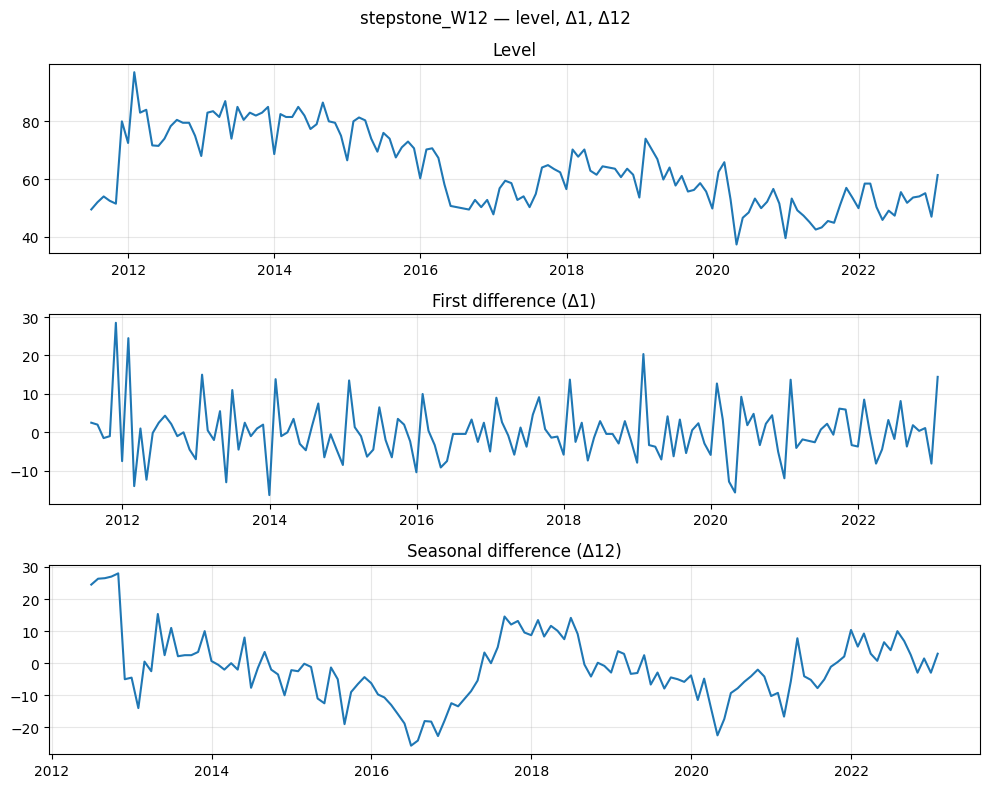

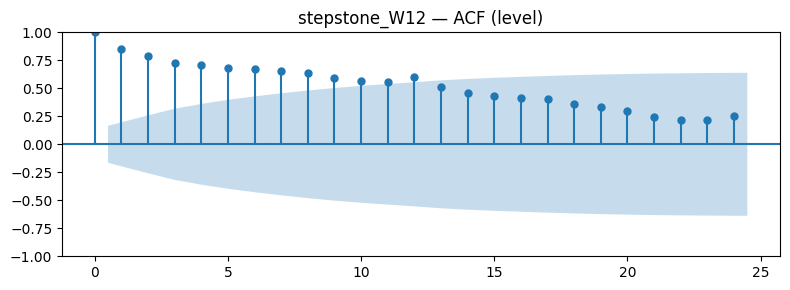

       series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
stepstone_W12     level  nc       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
stepstone_W12     level   c   -1.6889  0.4368   13.0000  126.0000       140    -3.4833    -2.8848     -2.5792        False        False         False
stepstone_W12     level  ct   -2.5111  0.3224   13.0000  126.0000       140    -4.0325    -3.4459     -3.1478        False        False         False
stepstone_W12     diff1  nc       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
stepstone_W12     diff1   c   -3.2986  0.0149   11.0000  127.0000       139    -3.4829    -2.8846     -2.5791        False         True          True
stepstone_W12     diff1  ct   -3.2441  0.0760   11.0000  127.0000       139    -4.0319    -3.4456   

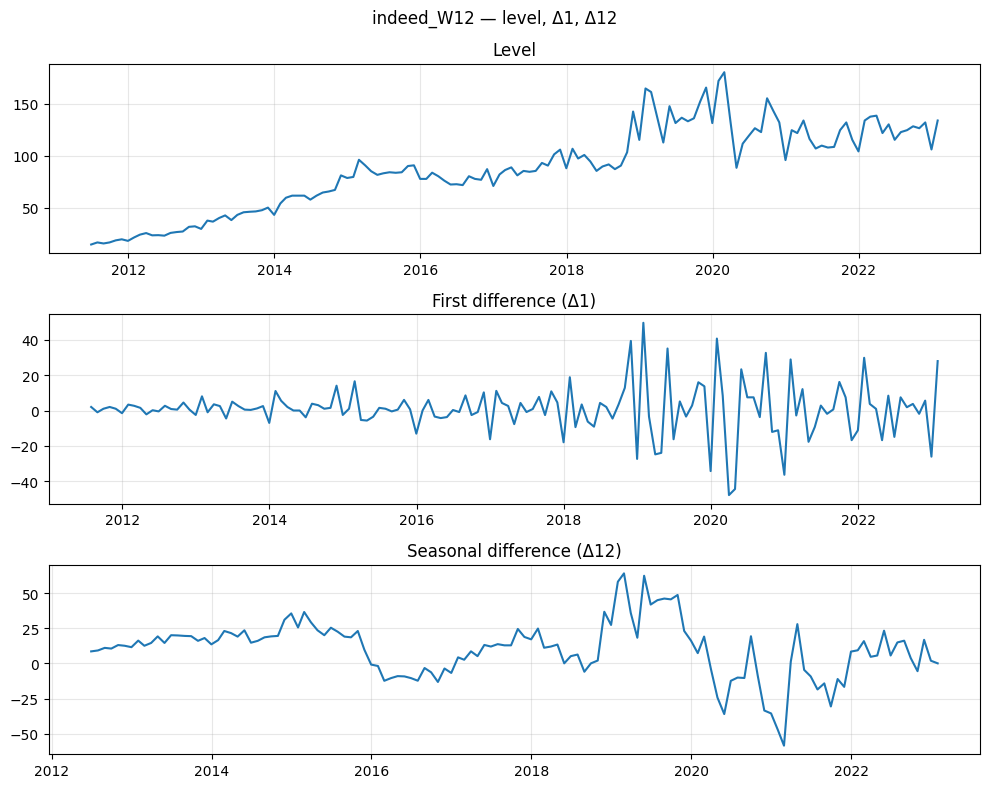

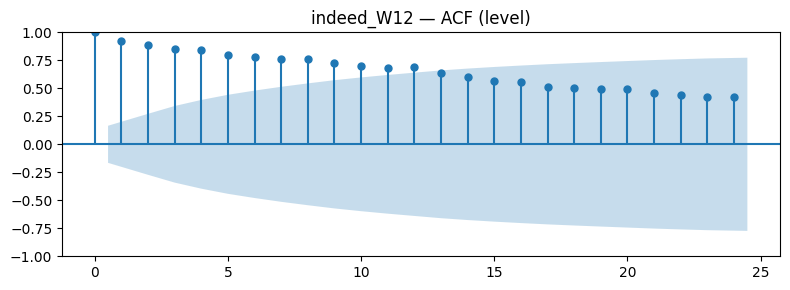

    series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
indeed_W12     level  nc       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
indeed_W12     level   c   -1.7090  0.4265   13.0000  126.0000       140    -3.4833    -2.8848     -2.5792        False        False         False
indeed_W12     level  ct   -2.5843  0.2872   14.0000  125.0000       140    -4.0331    -3.4462     -3.1480        False        False         False
indeed_W12     diff1  nc       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
indeed_W12     diff1   c   -3.4112  0.0106   11.0000  127.0000       139    -3.4829    -2.8846     -2.5791        False         True          True
indeed_W12     diff1  ct   -3.5863  0.0310   11.0000  127.0000       139    -4.0319    -3.4456     -3.1477        Fals

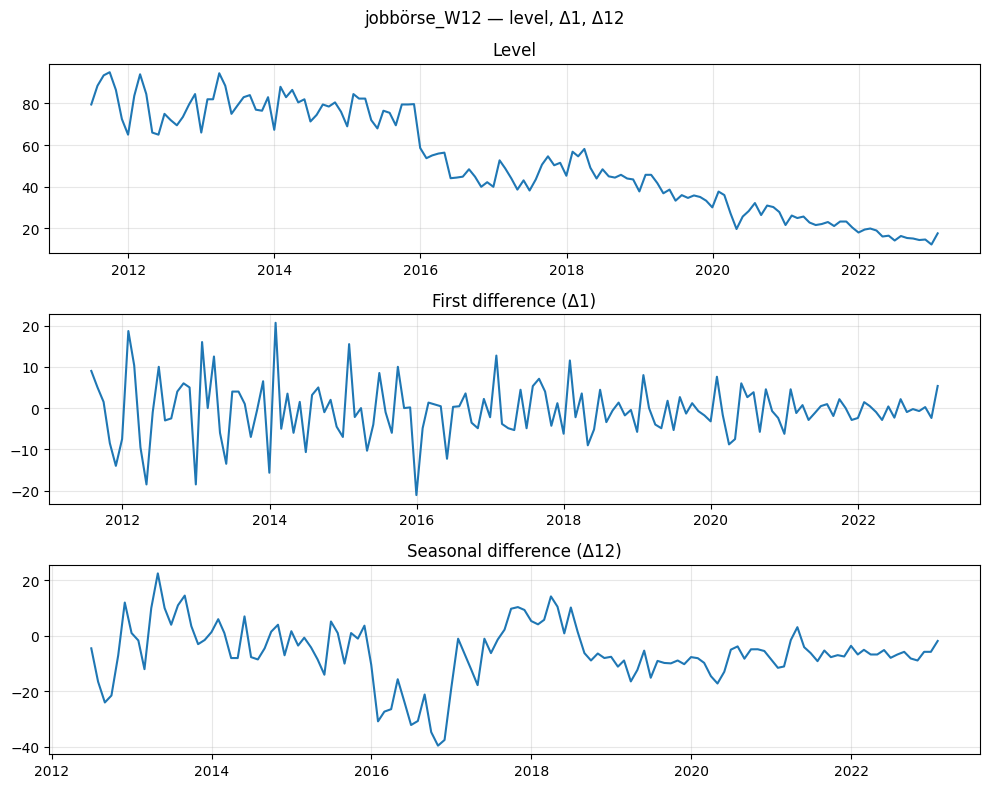

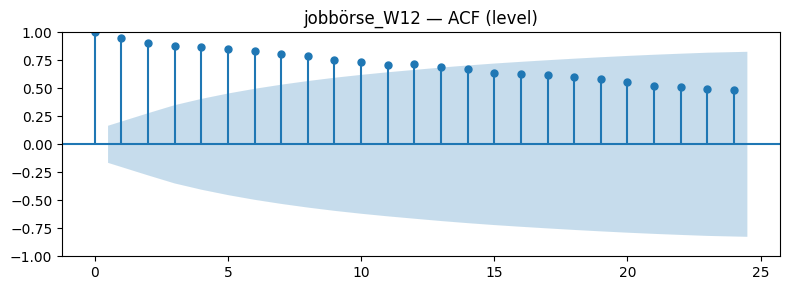

      series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
jobbörse_W12     level  nc       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
jobbörse_W12     level   c   -0.2388  0.9337   12.0000  127.0000       140    -3.4829    -2.8846     -2.5791        False        False         False
jobbörse_W12     level  ct   -4.1464  0.0054   14.0000  125.0000       140    -4.0331    -3.4462     -3.1480         True         True          True
jobbörse_W12     diff1  nc       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
jobbörse_W12     diff1   c   -3.4973  0.0081   11.0000  127.0000       139    -3.4829    -2.8846     -2.5791         True         True          True
jobbörse_W12     diff1  ct   -3.5209  0.0372   11.0000  127.0000       139    -4.0319    -3.4456     -3.14

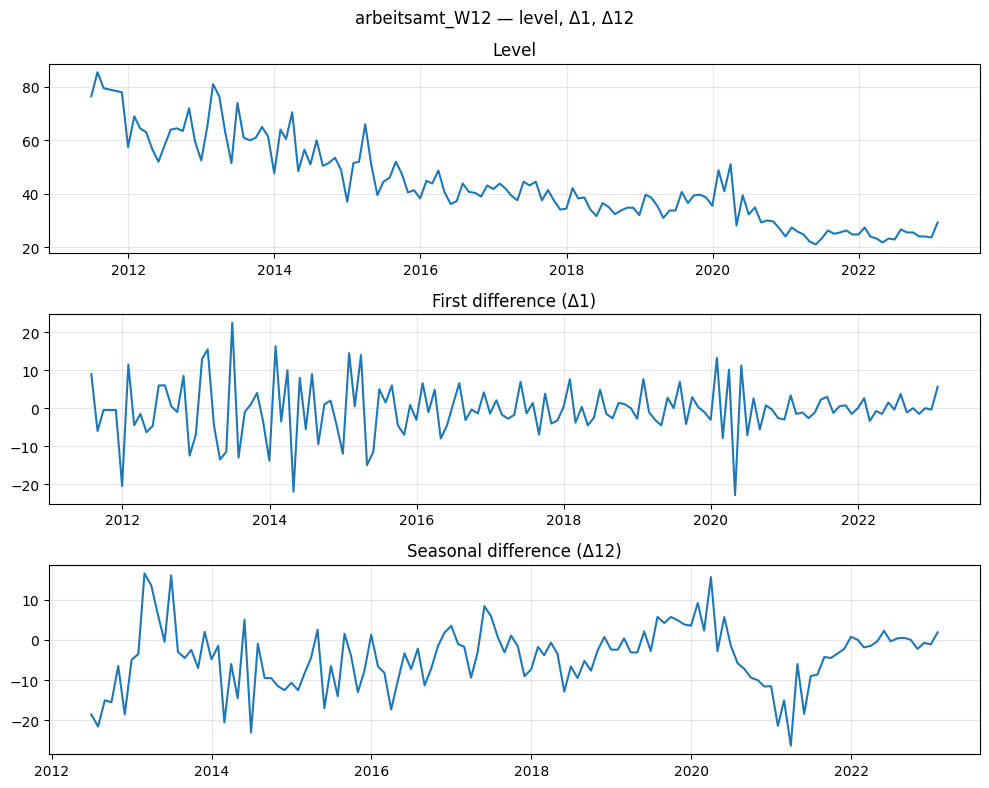

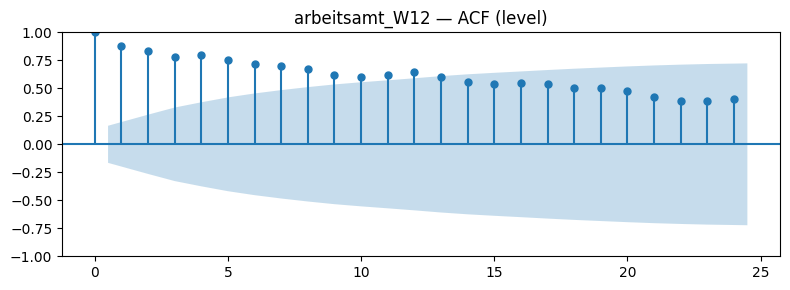

        series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
arbeitsamt_W12     level  nc       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
arbeitsamt_W12     level   c   -0.8870  0.7922   11.0000  128.0000       140    -3.4825    -2.8844     -2.5790        False        False         False
arbeitsamt_W12     level  ct   -1.7611  0.7232   11.0000  128.0000       140    -4.0313    -3.4454     -3.1475        False        False         False
arbeitsamt_W12     diff1  nc       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
arbeitsamt_W12     diff1   c   -6.0830  0.0000   10.0000  128.0000       139    -3.4825    -2.8844     -2.5790         True         True          True
arbeitsamt_W12     diff1  ct   -6.0501  0.0000   10.0000  128.0000       139    -4.0313    -3.

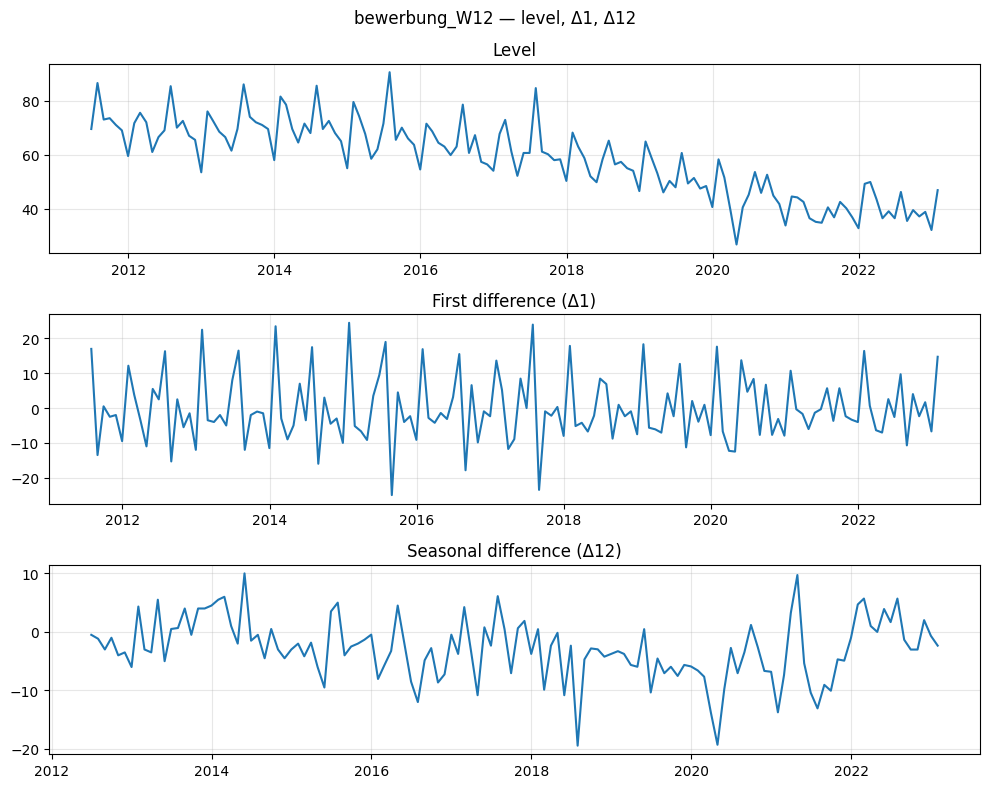

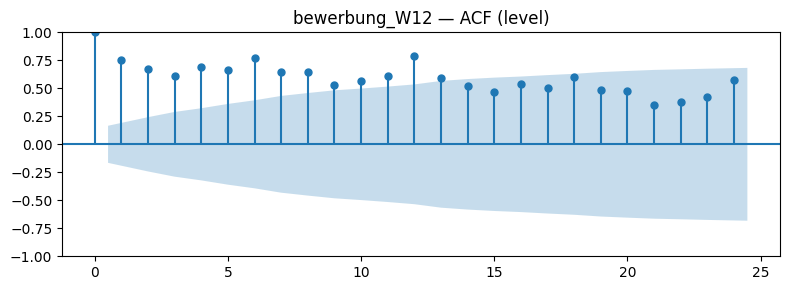

       series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
bewerbung_W12     level  nc       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
bewerbung_W12     level   c    0.6631  0.9891   12.0000  127.0000       140    -3.4829    -2.8846     -2.5791        False        False         False
bewerbung_W12     level  ct   -2.0718  0.5619   12.0000  127.0000       140    -4.0319    -3.4456     -3.1477        False        False         False
bewerbung_W12     diff1  nc       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
bewerbung_W12     diff1   c   -5.5274  0.0000   11.0000  127.0000       139    -3.4829    -2.8846     -2.5791         True         True          True
bewerbung_W12     diff1  ct   -5.7034  0.0000   11.0000  127.0000       139    -4.0319    -3.4456   

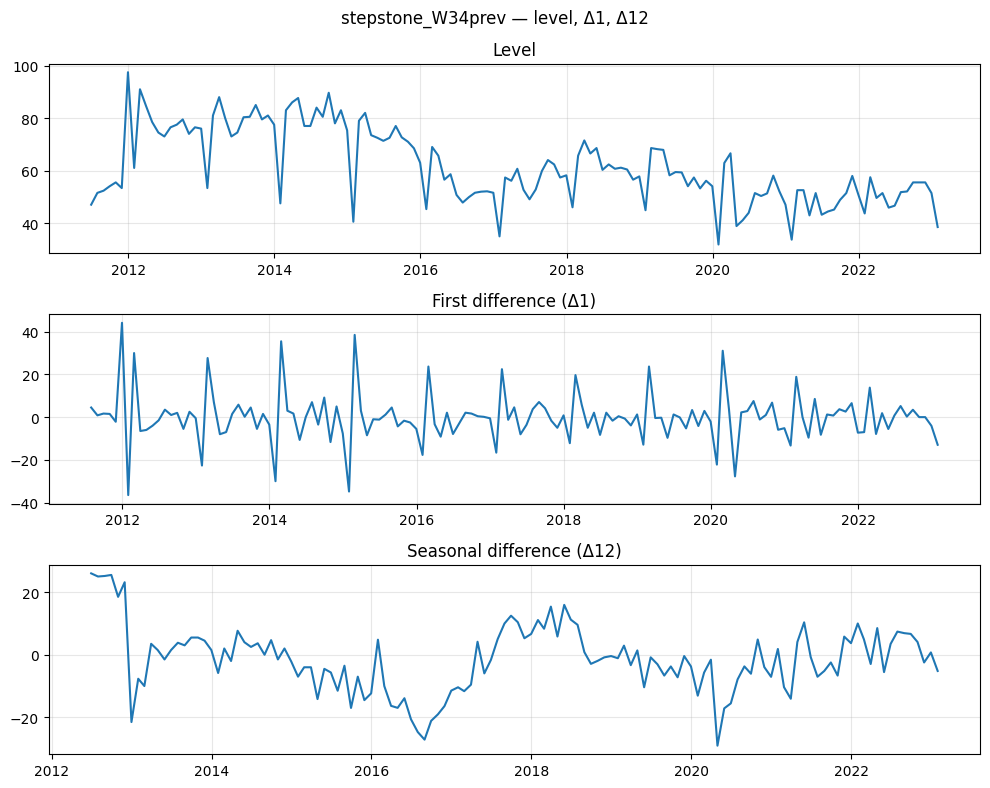

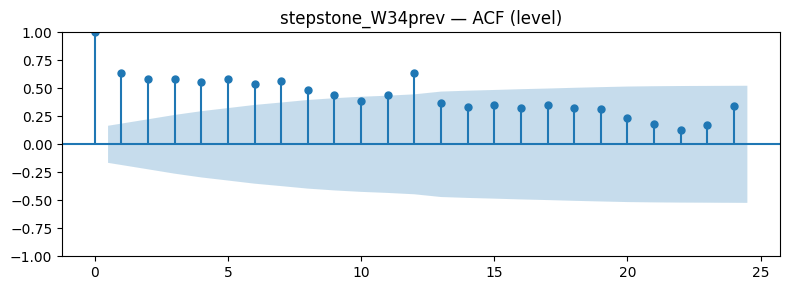

           series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
stepstone_W34prev     level  nc       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
stepstone_W34prev     level   c   -1.4172  0.5740   13.0000  126.0000       140    -3.4833    -2.8848     -2.5792        False        False         False
stepstone_W34prev     level  ct   -2.4308  0.3634   13.0000  126.0000       140    -4.0325    -3.4459     -3.1478        False        False         False
stepstone_W34prev     diff1  nc       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
stepstone_W34prev     diff1   c   -4.1487  0.0008   11.0000  127.0000       139    -3.4829    -2.8846     -2.5791         True         True          True
stepstone_W34prev     diff1  ct   -4.1088  0.0061   11.0000  127.0000       

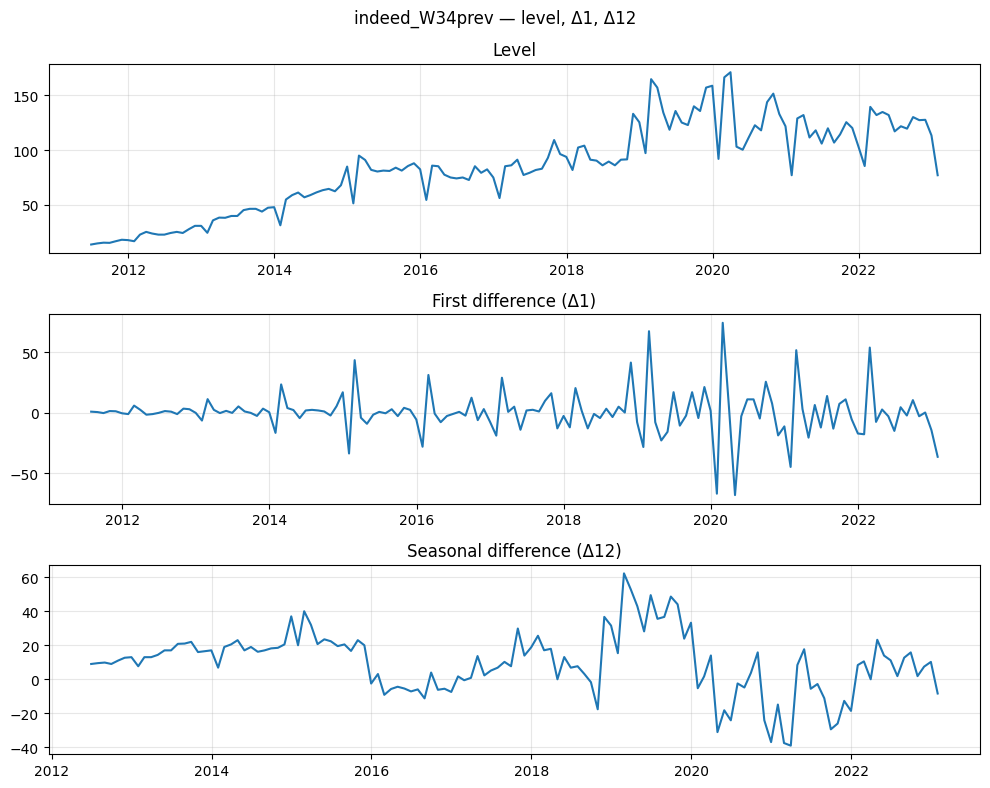

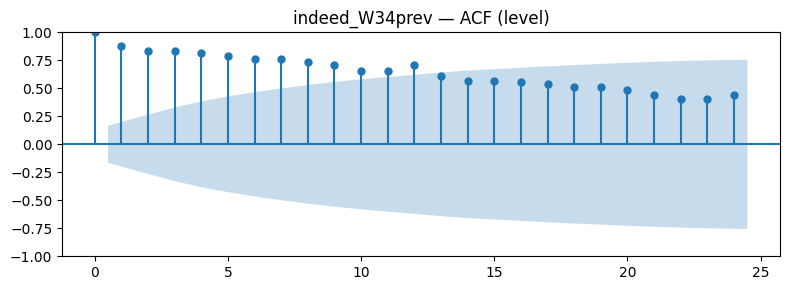

        series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
indeed_W34prev     level  nc       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
indeed_W34prev     level   c   -1.8303  0.3655   13.0000  126.0000       140    -3.4833    -2.8848     -2.5792        False        False         False
indeed_W34prev     level  ct   -2.4562  0.3502   14.0000  125.0000       140    -4.0331    -3.4462     -3.1480        False        False         False
indeed_W34prev     diff1  nc       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
indeed_W34prev     diff1   c   -2.8126  0.0565   14.0000  124.0000       139    -3.4842    -2.8851     -2.5794        False        False          True
indeed_W34prev     diff1  ct   -3.1291  0.0995   14.0000  124.0000       139    -4.0337    -3.

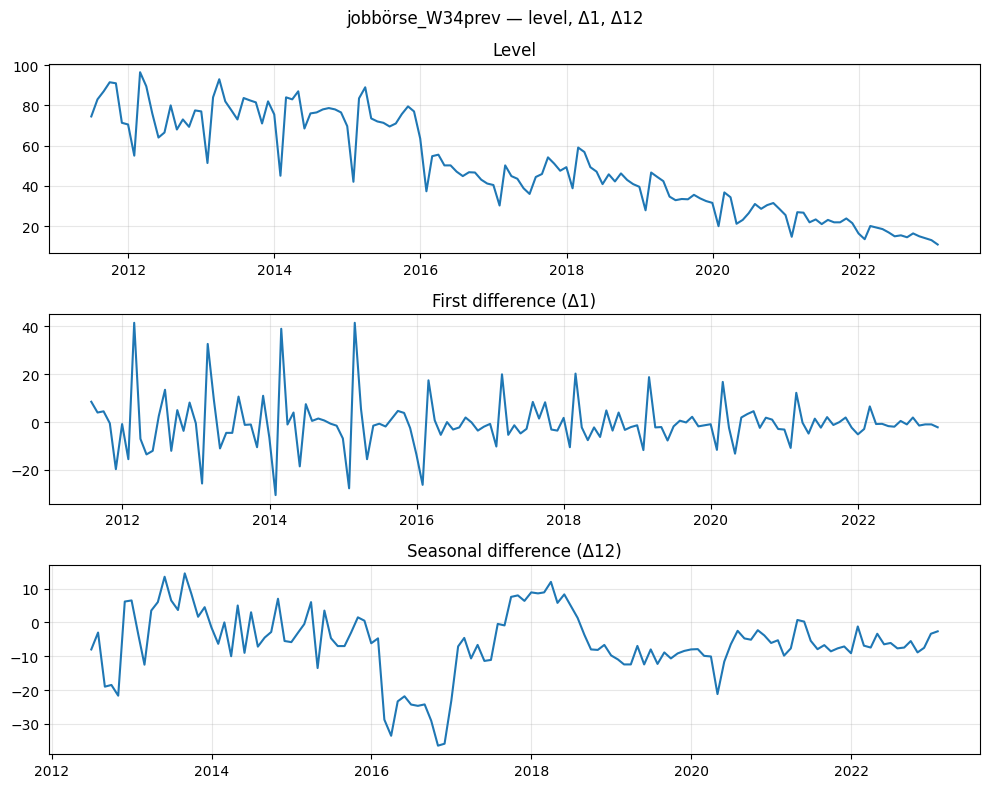

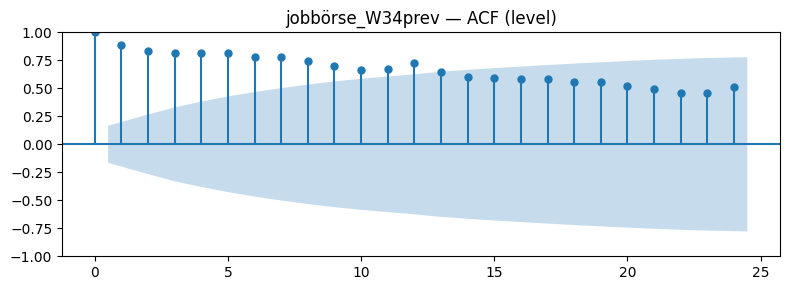

          series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
jobbörse_W34prev     level  nc       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
jobbörse_W34prev     level   c   -0.1995  0.9386   12.0000  127.0000       140    -3.4829    -2.8846     -2.5791        False        False         False
jobbörse_W34prev     level  ct   -3.0425  0.1206   12.0000  127.0000       140    -4.0319    -3.4456     -3.1477        False        False         False
jobbörse_W34prev     diff1  nc       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
jobbörse_W34prev     diff1   c   -3.5185  0.0075   11.0000  127.0000       139    -3.4829    -2.8846     -2.5791         True         True          True
jobbörse_W34prev     diff1  ct   -3.5403  0.0353   11.0000  127.0000       139    

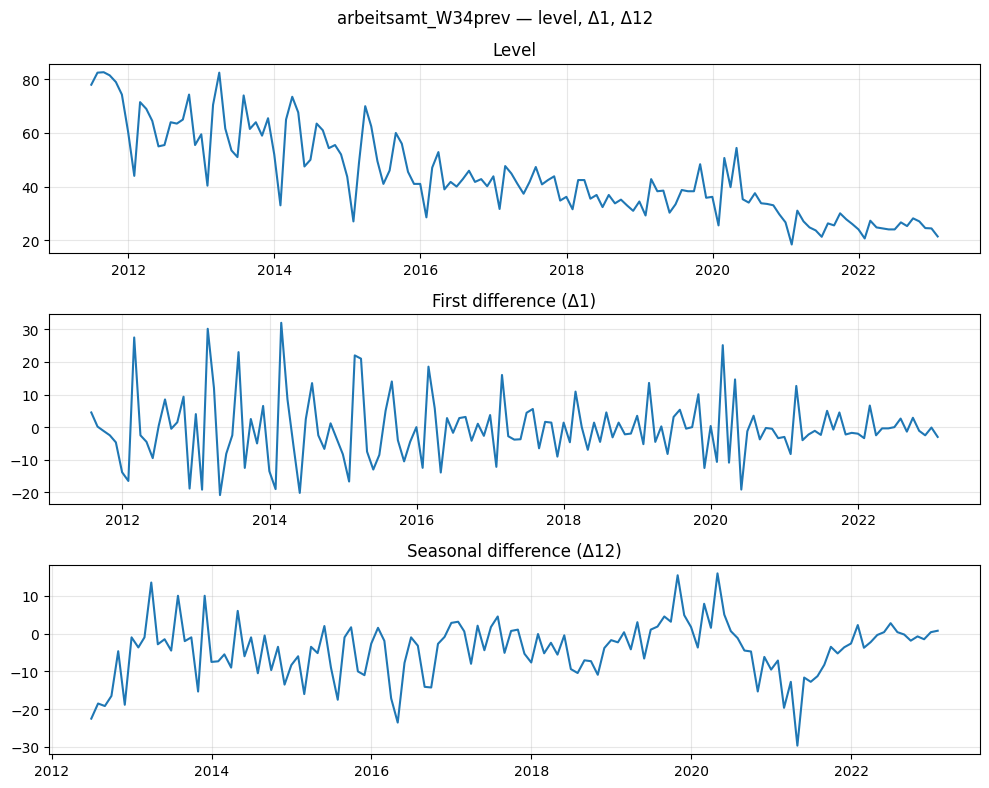

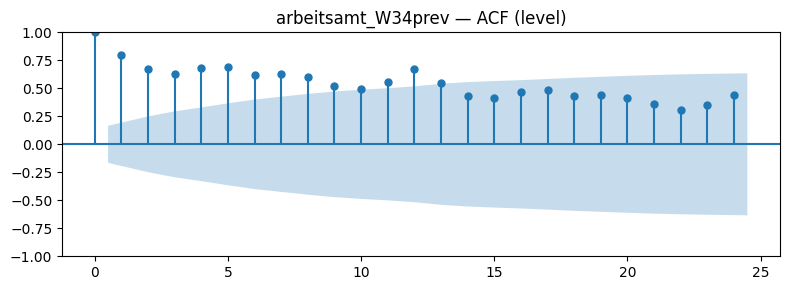

            series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
arbeitsamt_W34prev     level  nc       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
arbeitsamt_W34prev     level   c   -0.8583  0.8014   13.0000  126.0000       140    -3.4833    -2.8848     -2.5792        False        False         False
arbeitsamt_W34prev     level  ct   -2.3105  0.4282   13.0000  126.0000       140    -4.0325    -3.4459     -3.1478        False        False         False
arbeitsamt_W34prev     diff1  nc       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
arbeitsamt_W34prev     diff1   c   -4.2226  0.0006   12.0000  126.0000       139    -3.4833    -2.8848     -2.5792         True         True          True
arbeitsamt_W34prev     diff1  ct   -4.2062  0.0044   12.0000  126.0000

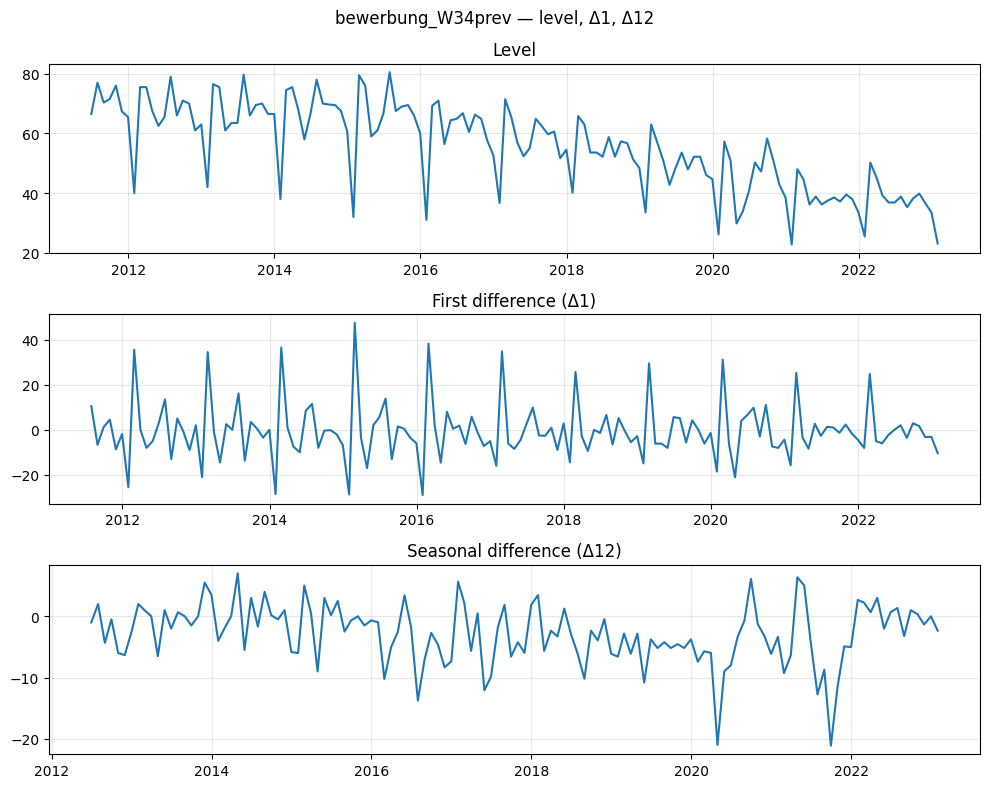

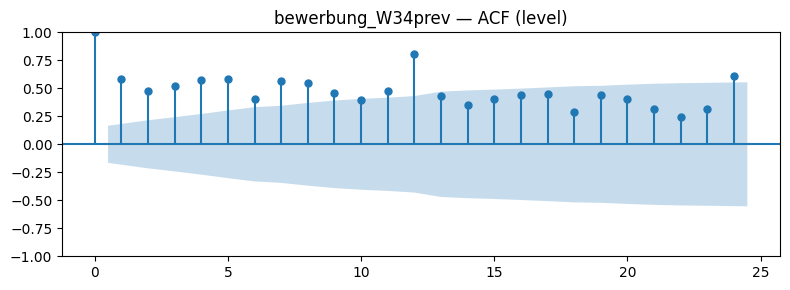

           series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
bewerbung_W34prev     level  nc       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
bewerbung_W34prev     level   c    1.0137  0.9944   12.0000  127.0000       140    -3.4829    -2.8846     -2.5791        False        False         False
bewerbung_W34prev     level  ct   -1.9437  0.6317   12.0000  127.0000       140    -4.0319    -3.4456     -3.1477        False        False         False
bewerbung_W34prev     diff1  nc       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
bewerbung_W34prev     diff1   c   -6.4150  0.0000   11.0000  127.0000       139    -3.4829    -2.8846     -2.5791         True         True          True
bewerbung_W34prev     diff1  ct   -6.6548  0.0000   11.0000  127.0000       

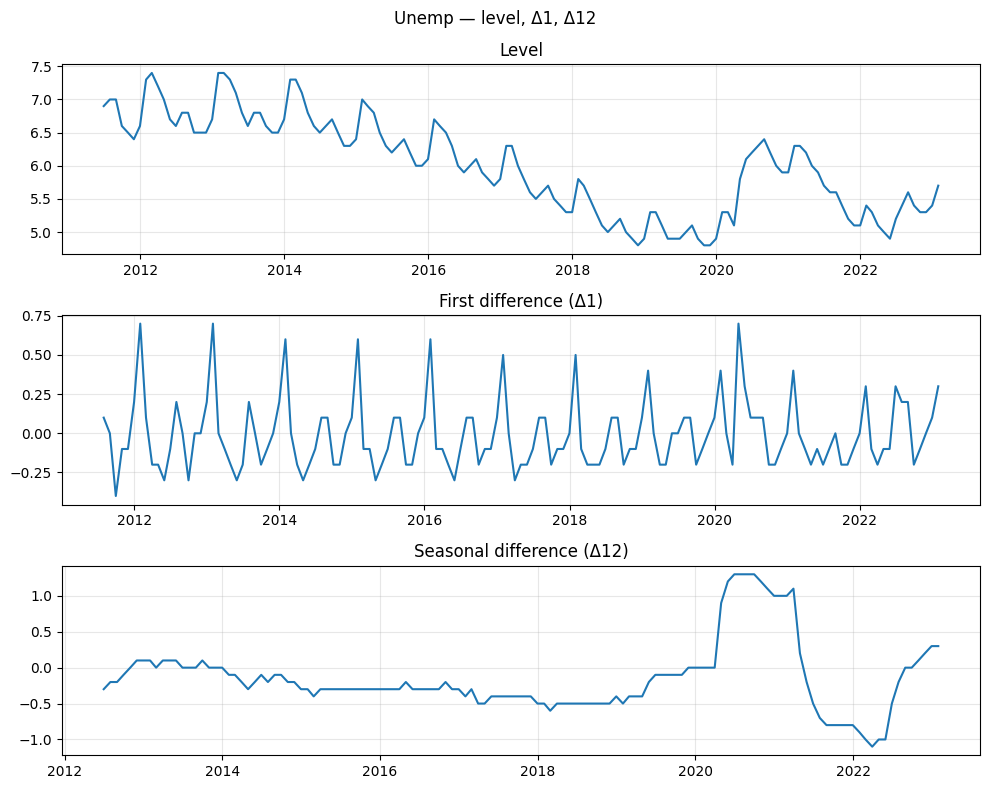

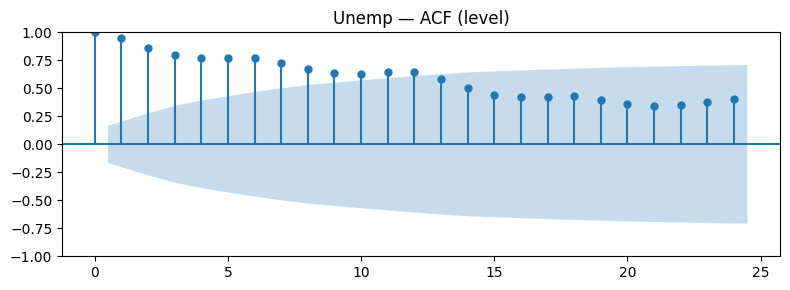

series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
 Unemp     level  nc       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
 Unemp     level   c   -1.4677  0.5494   14.0000  125.0000       140    -3.4838    -2.8850     -2.5793        False        False         False
 Unemp     level  ct   -2.2009  0.4893   14.0000  125.0000       140    -4.0331    -3.4462     -3.1480        False        False         False
 Unemp     diff1  nc       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
 Unemp     diff1   c   -2.8798  0.0478   13.0000  125.0000       139    -3.4838    -2.8850     -2.5793        False        False          True
 Unemp     diff1  ct   -2.8828  0.1682   13.0000  125.0000       139    -4.0331    -3.4462     -3.1480        False        False         False

In [15]:
# =========================
# Complete ADF test battery
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

# ----------------- Config -----------------
PLOT_SERIES = True      # set False to skip line plots
PLOT_ACF = True         # set False to skip ACF
ACF_MAXLAG = 24
MIN_LEN = 20            # minimum raw length to even attempt an ADF
MAXLAG = None           # None -> autolag="AIC"; else set an int (e.g., 12)
OUT_CSV = "adf_summary.csv"

# If your working DataFrame is 'panel_ecm', switch this:
# panel = panel_ecm

# ----------------- Helpers -----------------
def infer_seasonal_period(index) -> int | None:
    """
    Infer a sensible seasonal period m from a DatetimeIndex frequency.
    Returns 12 for monthly, 4 for quarterly, 7 for daily (weekly seasonality),
    52 for weekly, 365 for daily (yearly) if frequency suggests it; else None.
    """
    if not isinstance(index, pd.DatetimeIndex):
        return None

    # Use pandas' frequency inference if available
    freq = pd.infer_freq(index)
    if freq is None:
        # fallback: try heuristic by average steps
        diffs = pd.Series(index[1:] - index[:-1]).dt.days.dropna()
        if diffs.empty:
            return None
        step = int(round(diffs.median()))
        if step == 1:   # daily data
            return 7    # weekly seasonality as a pragmatic default
        return None

    f = freq.upper()

    # common cases
    if f.startswith("M"):   # month end/begin
        return 12
    if f.startswith("Q"):   # quarter end/begin
        return 4
    if f.startswith("W"):   # weekly
        return 52
    if f in ("D", "B"):     # daily or business daily
        return 7            # default to weekly cycle for daily data
    if f.startswith("H"):
        return 24
    return None

def adf_all(y: pd.Series,
            name: str,
            maxlag: int | None = None,
            min_len: int = 20,
            seasonal_period: int | None = None) -> pd.DataFrame:
    """
    Run ADF under regressions: 'nc', 'c', 'ct' on
    - level
    - first difference (Δ1)
    - seasonal difference (Δm) if m provided
    Returns a tidy DataFrame with stats, pvalues, used lag, obs counts, and critical values.
    """
    y = pd.Series(y, copy=False)
    cols = [
        "series","transform","reg",
        "adf_stat","pvalue",
        "used_lag","nobs_eff","nobs_raw",
        "crit_1pct","crit_5pct","crit_10pct",
        "reject_1pct","reject_5pct","reject_10pct"
    ]
    out = []

    def run_one(series, transform_label):
        series = pd.Series(series).dropna()
        nraw = int(series.shape[0])
        if nraw < min_len:
            for reg in ("nc","c","ct"):
                out.append((name, transform_label, reg,
                            np.nan, np.nan,
                            np.nan, np.nan, nraw,
                            np.nan, np.nan, np.nan,
                            False, False, False))
            return

        for reg in ("nc","c","ct"):
            try:
                stat, p, usedlag, nobs, crit, icbest = adfuller(
                    series,
                    regression=reg,
                    autolag="AIC" if maxlag is None else None,
                    maxlag=maxlag
                )
                c1, c5, c10 = crit.get("1%"), crit.get("5%"), crit.get("10%")
                # ADF rejects if stat is MORE NEGATIVE than critical value
                r1 = bool((stat is not None) and (c1 is not None) and (stat < c1))
                r5 = bool((stat is not None) and (c5 is not None) and (stat < c5))
                r10 = bool((stat is not None) and (c10 is not None) and (stat < c10))
                out.append((name, transform_label, reg,
                            stat, p,
                            usedlag, nobs, nraw,
                            c1, c5, c10,
                            r1, r5, r10))
            except Exception:
                out.append((name, transform_label, reg,
                            np.nan, np.nan,
                            np.nan, np.nan, nraw,
                            np.nan, np.nan, np.nan,
                            False, False, False))

    # Level
    run_one(y, "level")
    # Δ1
    run_one(y.diff(), "diff1")
    # Δm (seasonal difference) if applicable
    if seasonal_period and seasonal_period >= 2:
        run_one(y.diff(seasonal_period), f"diff{seasonal_period}")

    return pd.DataFrame(out, columns=cols)

# ----------------- Main: per-column analysis -----------------
all_results = []
for col in panel.columns:
    s = pd.to_numeric(panel[col], errors="coerce")
    s_level = s.dropna()
    m = infer_seasonal_period(s.index)

    print("\n" + "="*80)
    print(f"{col} — lengths")
    print(f"level  raw n = {s_level.shape[0]}")
    print(f"Δ1     raw n = {s.diff().dropna().shape[0]}")
    if m:
        print(f"Δ{m:<5} raw n = {s.diff(m).dropna().shape[0]}")

    # Optional plots
    if PLOT_SERIES:
        fig, axes = plt.subplots(3 if m else 2, 1, figsize=(10, 8 if m else 6), sharex=False)
        fig.suptitle(f"{col} — level, Δ1" + (f", Δ{m}" if m else ""), y=0.98)
        # level
        if not s_level.empty:
            axes[0].plot(s_level.index, s_level.values)
        axes[0].set_title("Level")
        axes[0].grid(True, alpha=0.3)
        # Δ1
        d1 = s.diff().dropna()
        if not d1.empty:
            axes[1].plot(d1.index, d1.values)
        axes[1].set_title("First difference (Δ1)")
        axes[1].grid(True, alpha=0.3)
        # Δm
        if m:
            dm = s.diff(m).dropna()
            if not dm.empty:
                axes[2].plot(dm.index, dm.values)
            axes[2].set_title(f"Seasonal difference (Δ{m})")
            axes[2].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    if PLOT_ACF:
        vals = s_level
        if len(vals) > ACF_MAXLAG:
            fig2, ax2 = plt.subplots(figsize=(8, 3))
            plot_acf(vals, ax=ax2, lags=ACF_MAXLAG)
            ax2.set_title(f"{col} — ACF (level)")
            plt.tight_layout()
            plt.show()

    # Run ADFs
    res = adf_all(
        s,
        name=col,
        maxlag=MAXLAG,
        min_len=MIN_LEN,
        seasonal_period=m
    )

    # Nice compact display for this series
    display_cols = [
        "series","transform","reg",
        "adf_stat","pvalue","used_lag","nobs_eff","nobs_raw",
        "crit_1pct","crit_5pct","crit_10pct",
        "reject_1pct","reject_5pct","reject_10pct"
    ]
    with pd.option_context("display.float_format", "{:,.4f}".format):
        print(res[display_cols].to_string(index=False))

    all_results.append(res)

# ----------------- Portfolio summary & export -----------------
adf_summary = pd.concat(all_results, ignore_index=True)

# convenience flags at 5%
adf_summary["reject_5pct_flag"] = adf_summary["reject_5pct"].astype(bool)

# What is stationary at level under ANY deterministic spec?
stationary_level_any = (
    adf_summary.query("transform=='level'")
               .groupby("series")["reject_5pct_flag"].any()
               .reset_index(name="reject_at_level_any_spec_5pct")
)

# Robust (ALL specs reject at 5%) — stricter
stationary_level_all = (
    adf_summary.query("transform=='level'")
               .groupby("series")["reject_5pct_flag"].all()
               .reset_index(name="reject_at_level_all_specs_5pct")
)

print("\n" + "-"*80)
print("Stationary at LEVEL (p<0.05) under ANY spec:")
print(stationary_level_any.to_string(index=False))
print("\nStationary at LEVEL (p<0.05) under ALL specs (strict):")
print(stationary_level_all.to_string(index=False))

# Best spec per transform by smallest p-value (for reporting)
best_by_p = (
    adf_summary
    .dropna(subset=["pvalue"])
    .sort_values(["series","transform","pvalue"], ascending=[True, True, True])
    .groupby(["series","transform"], as_index=False)
    .first()[["series","transform","reg","adf_stat","pvalue","used_lag","nobs_eff"]]
    .rename(columns={"reg":"best_reg_by_min_p"})
)
print("\nBest ADF (min p-value) per series x transform:")
with pd.option_context("display.float_format", "{:,.4f}".format):
    print(best_by_p.to_string(index=False))

# Save full tidy table
adf_summary.to_csv(OUT_CSV, index=False)
print(f"\nSaved full results to: {OUT_CSV}")


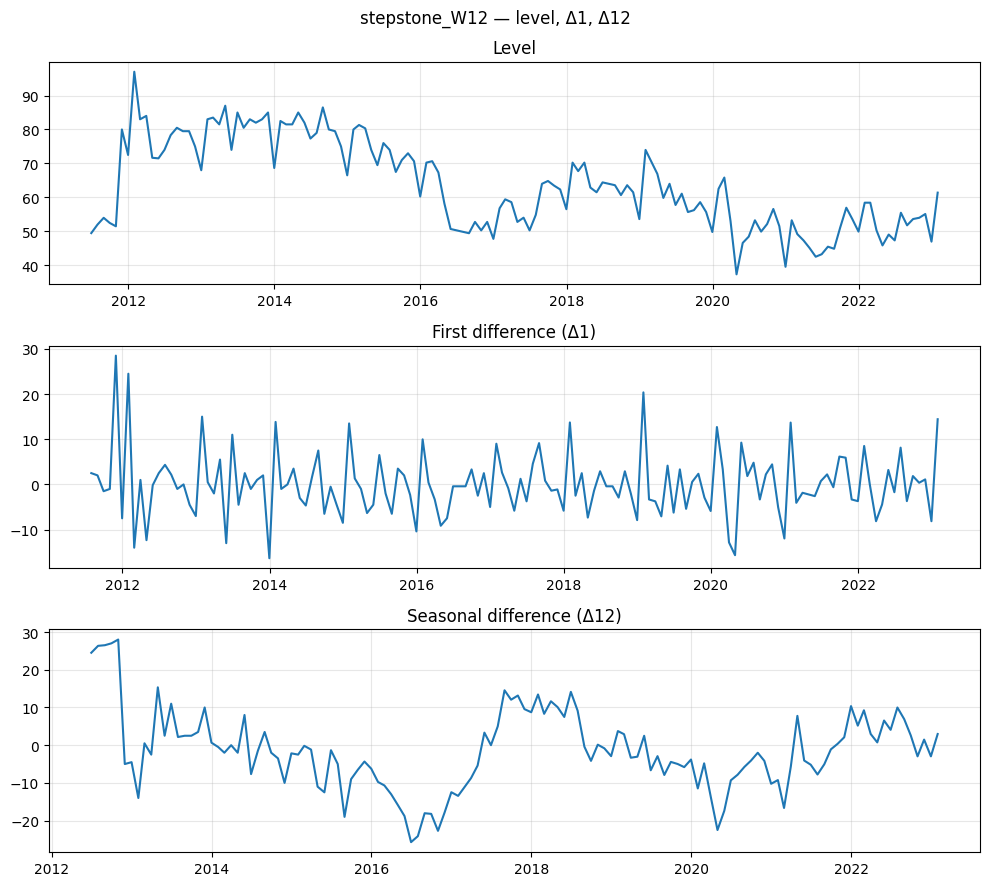

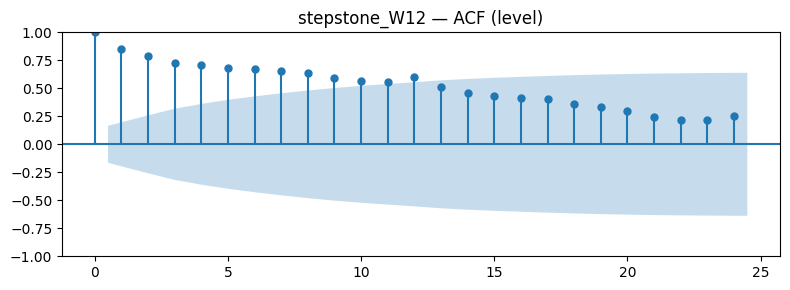

       series transform reg  adf_stat   pvalue  used_lag
stepstone_W12     level  nc       NaN      NaN       NaN
stepstone_W12     level   c -1.688886 0.436848      13.0
stepstone_W12     level  ct -2.511077 0.322446      13.0
stepstone_W12     diff1  nc       NaN      NaN       NaN
stepstone_W12     diff1   c -3.298578 0.014942      11.0
stepstone_W12     diff1  ct -3.244137 0.075960      11.0
stepstone_W12    diff12  nc       NaN      NaN       NaN
stepstone_W12    diff12   c -2.737359 0.067794      13.0
stepstone_W12    diff12  ct -2.692231 0.239323      13.0


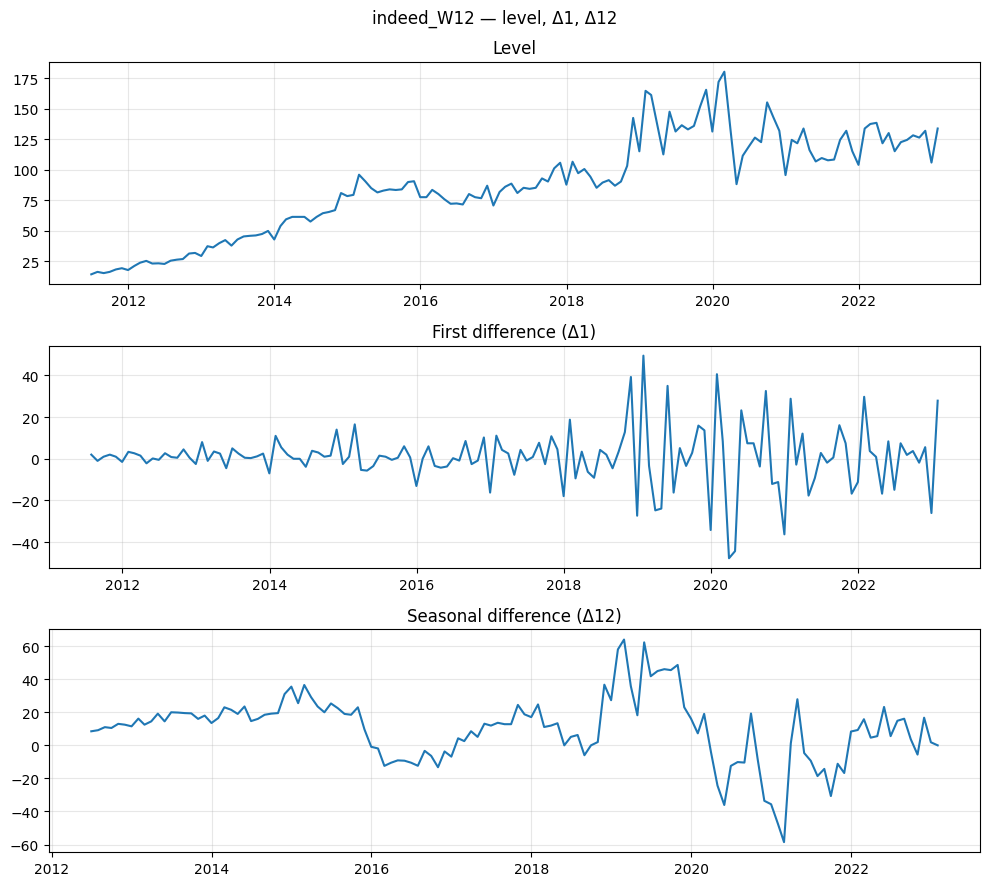

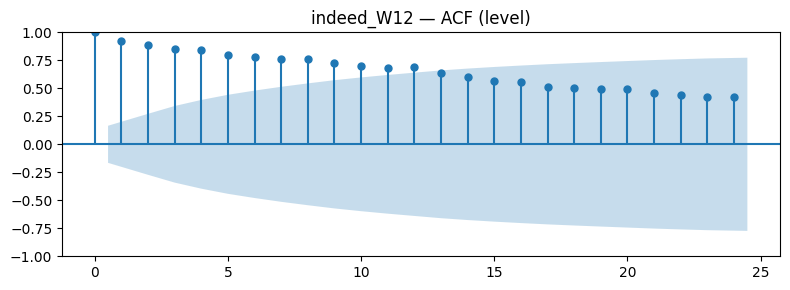

    series transform reg  adf_stat   pvalue  used_lag
indeed_W12     level  nc       NaN      NaN       NaN
indeed_W12     level   c -1.709013 0.426475      13.0
indeed_W12     level  ct -2.584270 0.287186      14.0
indeed_W12     diff1  nc       NaN      NaN       NaN
indeed_W12     diff1   c -3.411165 0.010584      11.0
indeed_W12     diff1  ct -3.586305 0.031023      11.0
indeed_W12    diff12  nc       NaN      NaN       NaN
indeed_W12    diff12   c -3.130336 0.024388      13.0
indeed_W12    diff12  ct -3.534577 0.035834      13.0


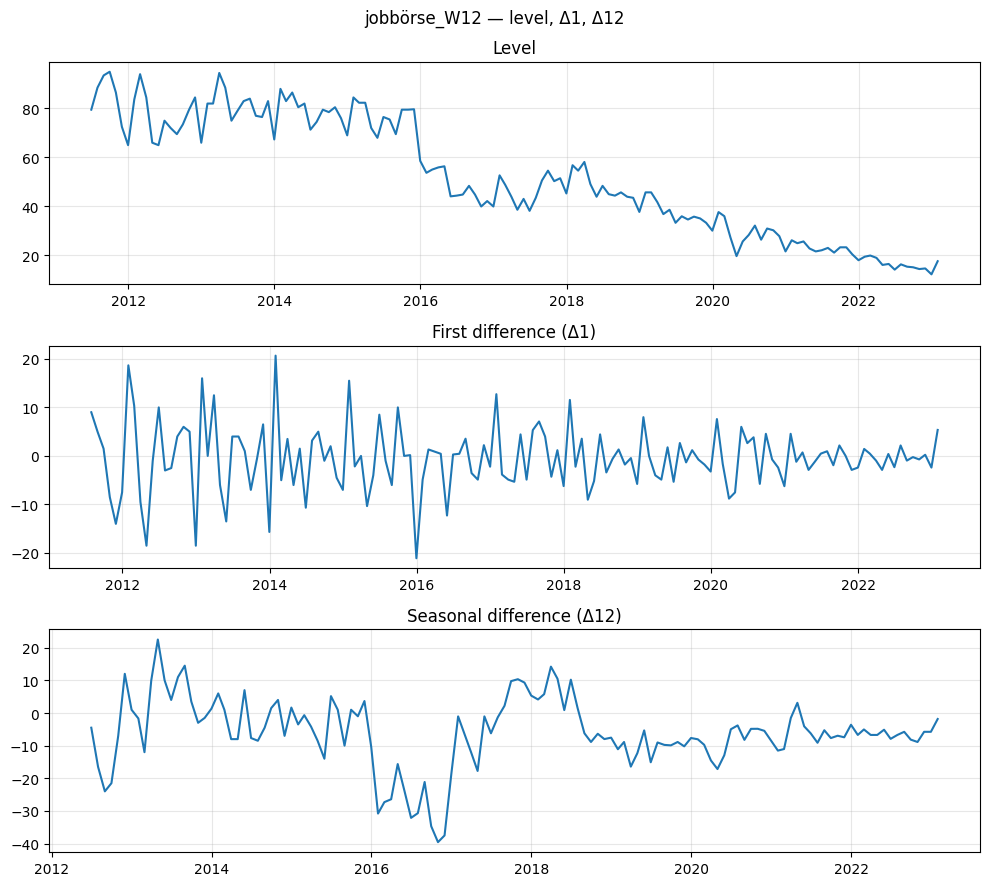

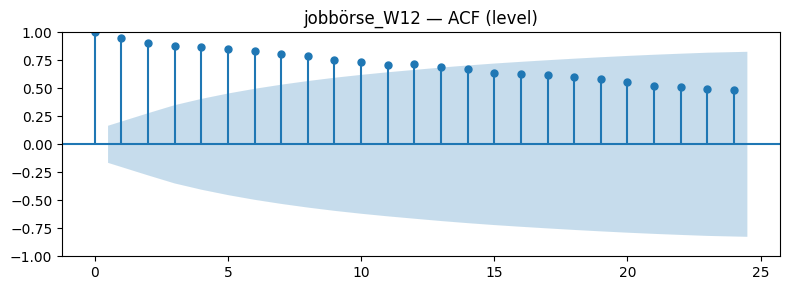

      series transform reg  adf_stat   pvalue  used_lag
jobbörse_W12     level  nc       NaN      NaN       NaN
jobbörse_W12     level   c -0.238802 0.933736      12.0
jobbörse_W12     level  ct -4.146423 0.005386      14.0
jobbörse_W12     diff1  nc       NaN      NaN       NaN
jobbörse_W12     diff1   c -3.497256 0.008058      11.0
jobbörse_W12     diff1  ct -3.520877 0.037209      11.0
jobbörse_W12    diff12  nc       NaN      NaN       NaN
jobbörse_W12    diff12   c -2.960626 0.038739      12.0
jobbörse_W12    diff12  ct -2.851081 0.178816      12.0


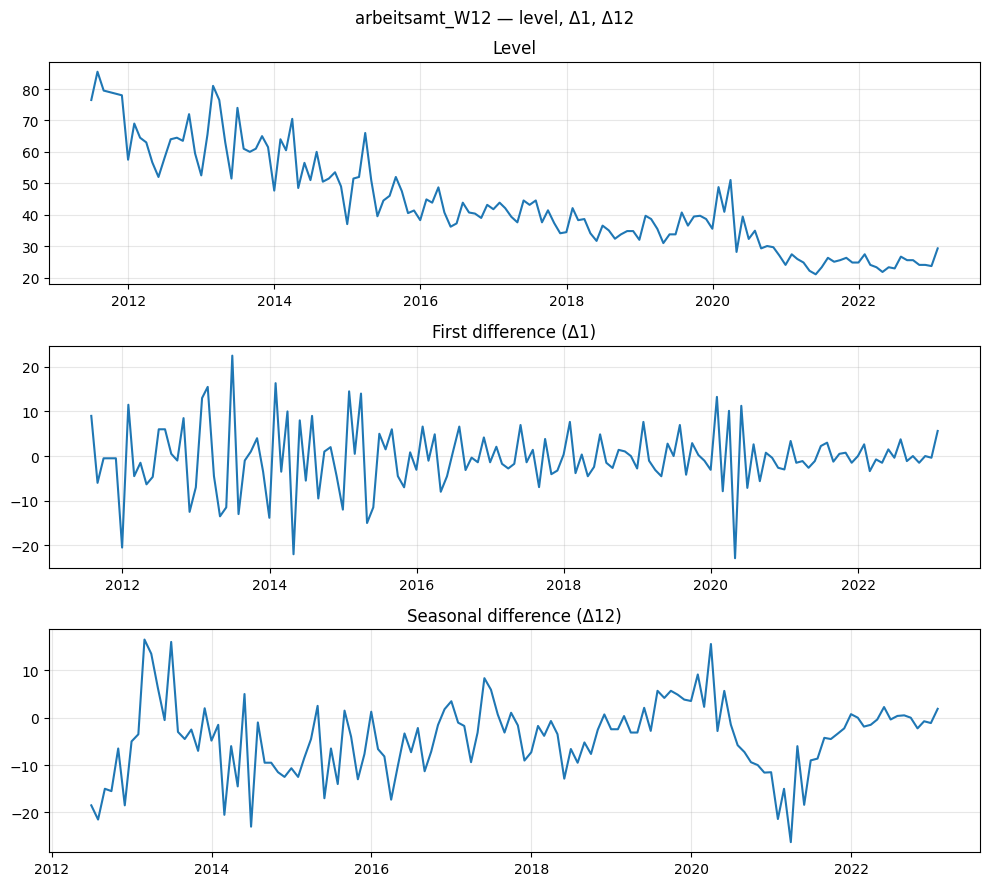

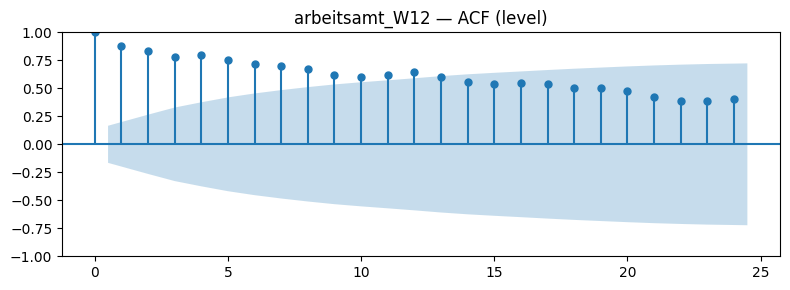

        series transform reg  adf_stat       pvalue  used_lag
arbeitsamt_W12     level  nc       NaN          NaN       NaN
arbeitsamt_W12     level   c -0.887023 7.922158e-01      11.0
arbeitsamt_W12     level  ct -1.761122 7.231963e-01      11.0
arbeitsamt_W12     diff1  nc       NaN          NaN       NaN
arbeitsamt_W12     diff1   c -6.083030 1.080737e-07      10.0
arbeitsamt_W12     diff1  ct -6.050095 1.722877e-06      10.0
arbeitsamt_W12    diff12  nc       NaN          NaN       NaN
arbeitsamt_W12    diff12   c -3.487645 8.310123e-03      12.0
arbeitsamt_W12    diff12  ct -3.934281 1.087833e-02      12.0


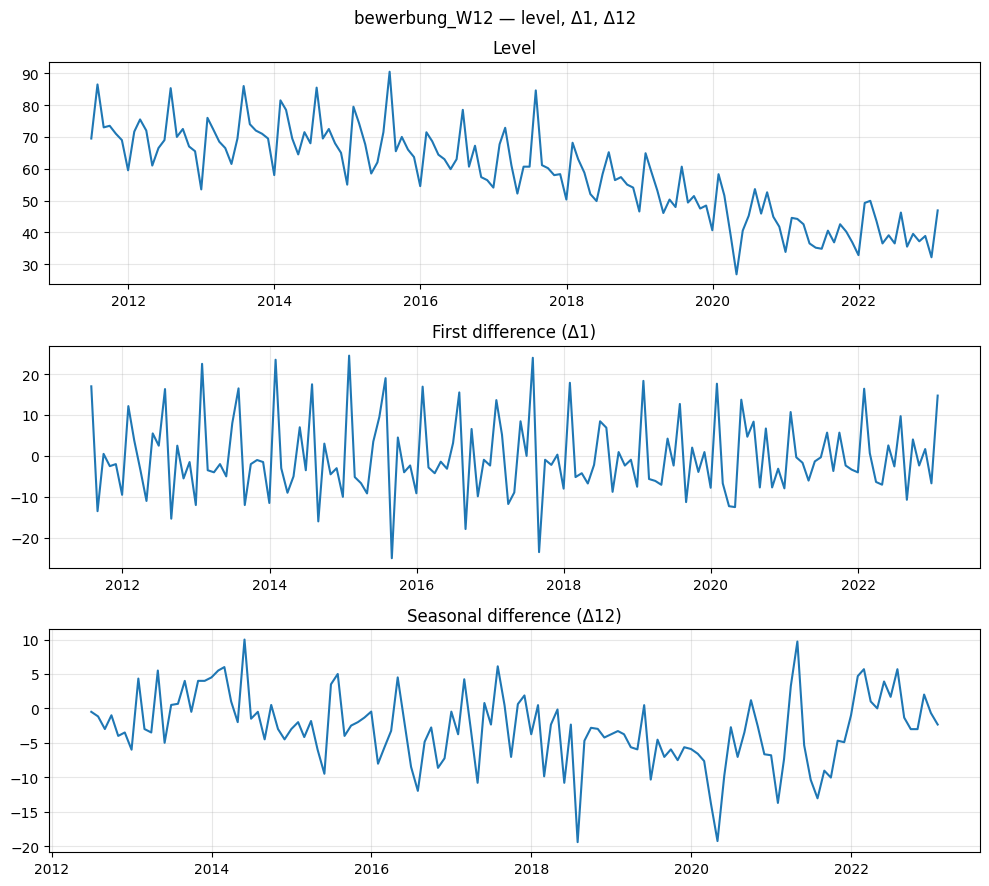

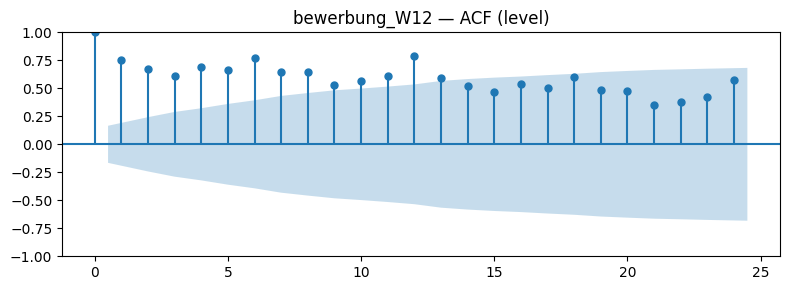

       series transform reg  adf_stat   pvalue  used_lag
bewerbung_W12     level  nc       NaN      NaN       NaN
bewerbung_W12     level   c  0.663084 0.989072      12.0
bewerbung_W12     level  ct -2.071782 0.561858      12.0
bewerbung_W12     diff1  nc       NaN      NaN       NaN
bewerbung_W12     diff1   c -5.527390 0.000002      11.0
bewerbung_W12     diff1  ct -5.703443 0.000009      11.0
bewerbung_W12    diff12  nc       NaN      NaN       NaN
bewerbung_W12    diff12   c -1.984775 0.293289      12.0
bewerbung_W12    diff12  ct -1.960263 0.622902      12.0


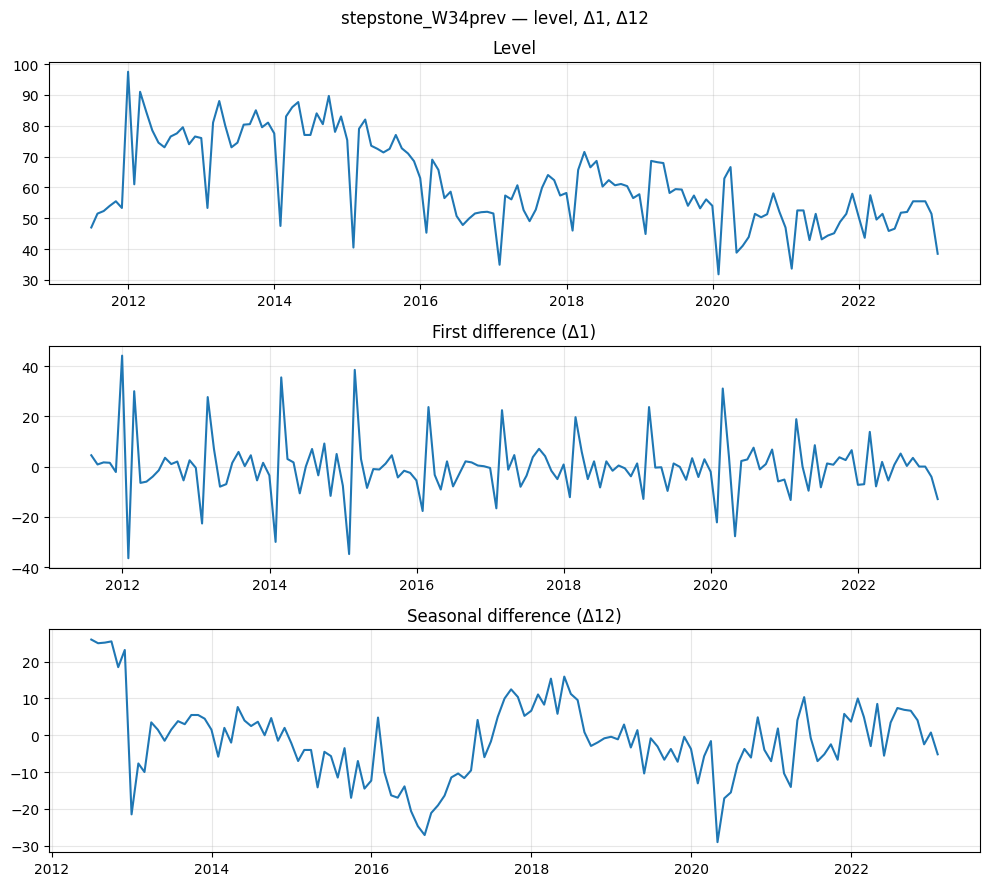

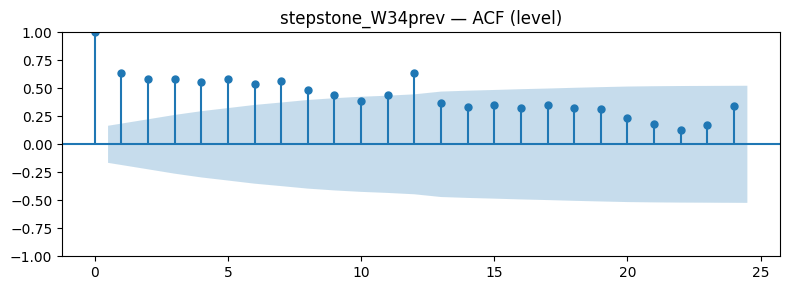

           series transform reg  adf_stat   pvalue  used_lag
stepstone_W34prev     level  nc       NaN      NaN       NaN
stepstone_W34prev     level   c -1.417214 0.573996      13.0
stepstone_W34prev     level  ct -2.430782 0.363386      13.0
stepstone_W34prev     diff1  nc       NaN      NaN       NaN
stepstone_W34prev     diff1   c -4.148709 0.000804      11.0
stepstone_W34prev     diff1  ct -4.108776 0.006122      11.0
stepstone_W34prev    diff12  nc       NaN      NaN       NaN
stepstone_W34prev    diff12   c -2.336198 0.160559      12.0
stepstone_W34prev    diff12  ct -2.320844 0.422457      12.0


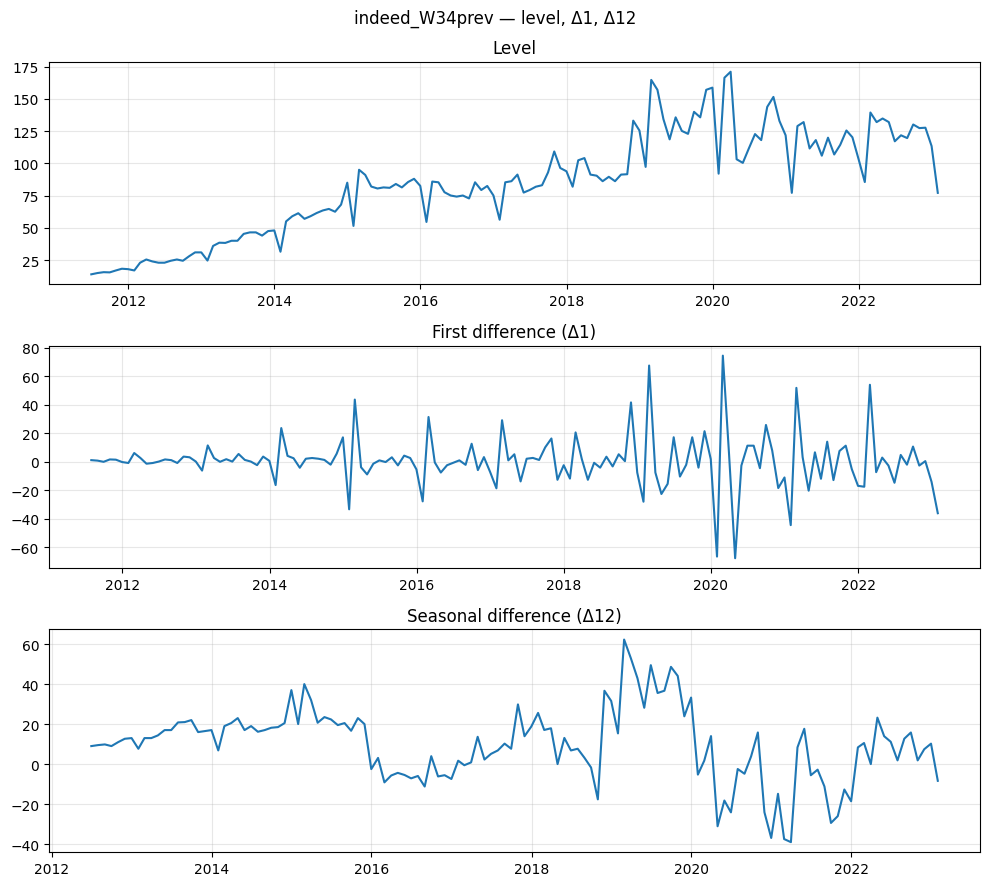

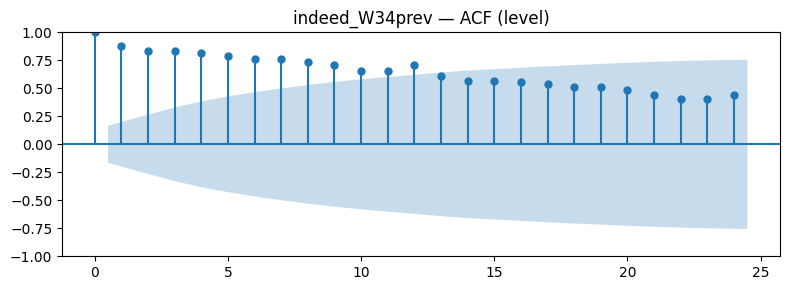

        series transform reg  adf_stat   pvalue  used_lag
indeed_W34prev     level  nc       NaN      NaN       NaN
indeed_W34prev     level   c -1.830257 0.365546      13.0
indeed_W34prev     level  ct -2.456210 0.350190      14.0
indeed_W34prev     diff1  nc       NaN      NaN       NaN
indeed_W34prev     diff1   c -2.812557 0.056502      14.0
indeed_W34prev     diff1  ct -3.129087 0.099480      14.0
indeed_W34prev    diff12  nc       NaN      NaN       NaN
indeed_W34prev    diff12   c -3.015326 0.033488      13.0
indeed_W34prev    diff12  ct -3.484481 0.041082      13.0


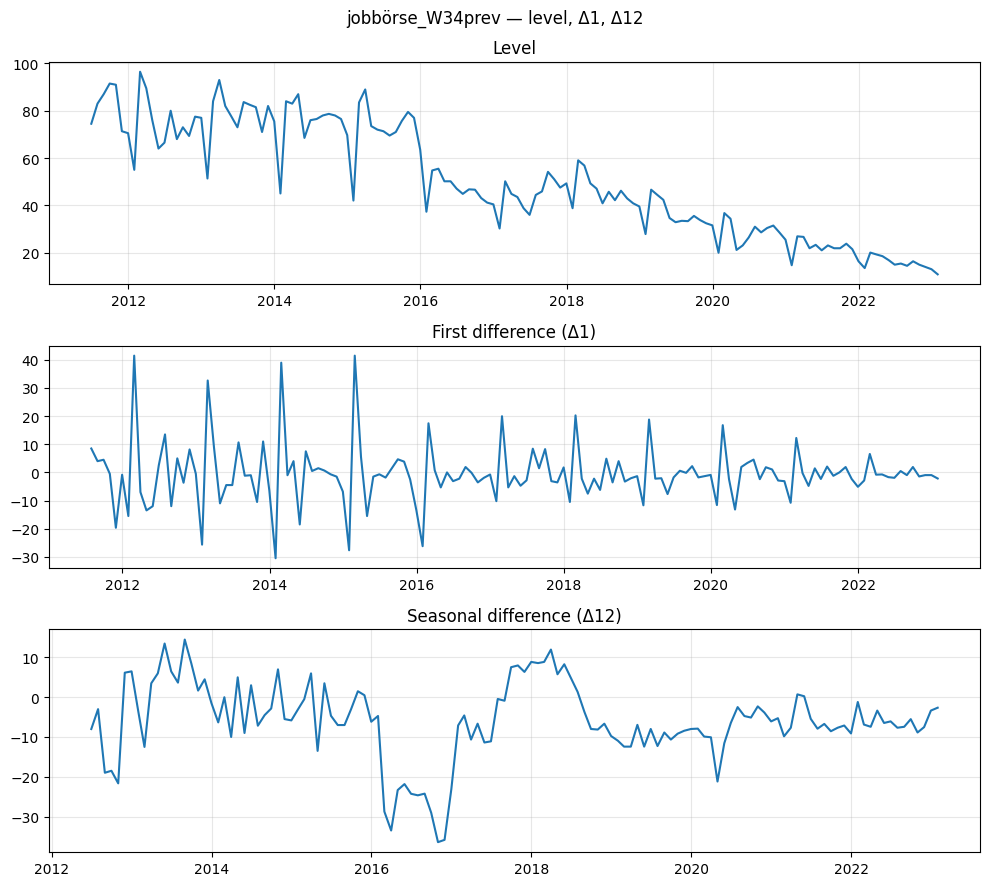

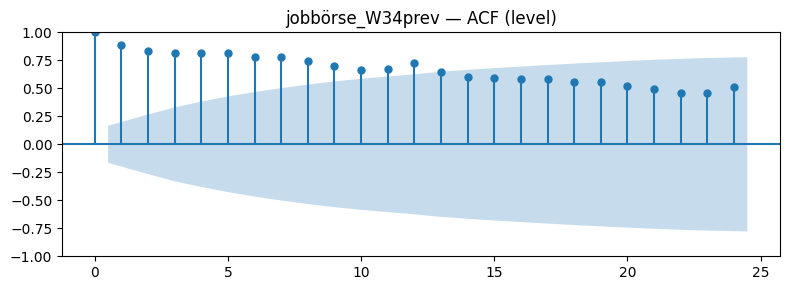

          series transform reg  adf_stat   pvalue  used_lag
jobbörse_W34prev     level  nc       NaN      NaN       NaN
jobbörse_W34prev     level   c -0.199455 0.938587      12.0
jobbörse_W34prev     level  ct -3.042454 0.120596      12.0
jobbörse_W34prev     diff1  nc       NaN      NaN       NaN
jobbörse_W34prev     diff1   c -3.518484 0.007525      11.0
jobbörse_W34prev     diff1  ct -3.540329 0.035270      11.0
jobbörse_W34prev    diff12  nc       NaN      NaN       NaN
jobbörse_W34prev    diff12   c -3.429425 0.009996      12.0
jobbörse_W34prev    diff12  ct -3.320720 0.062916      12.0


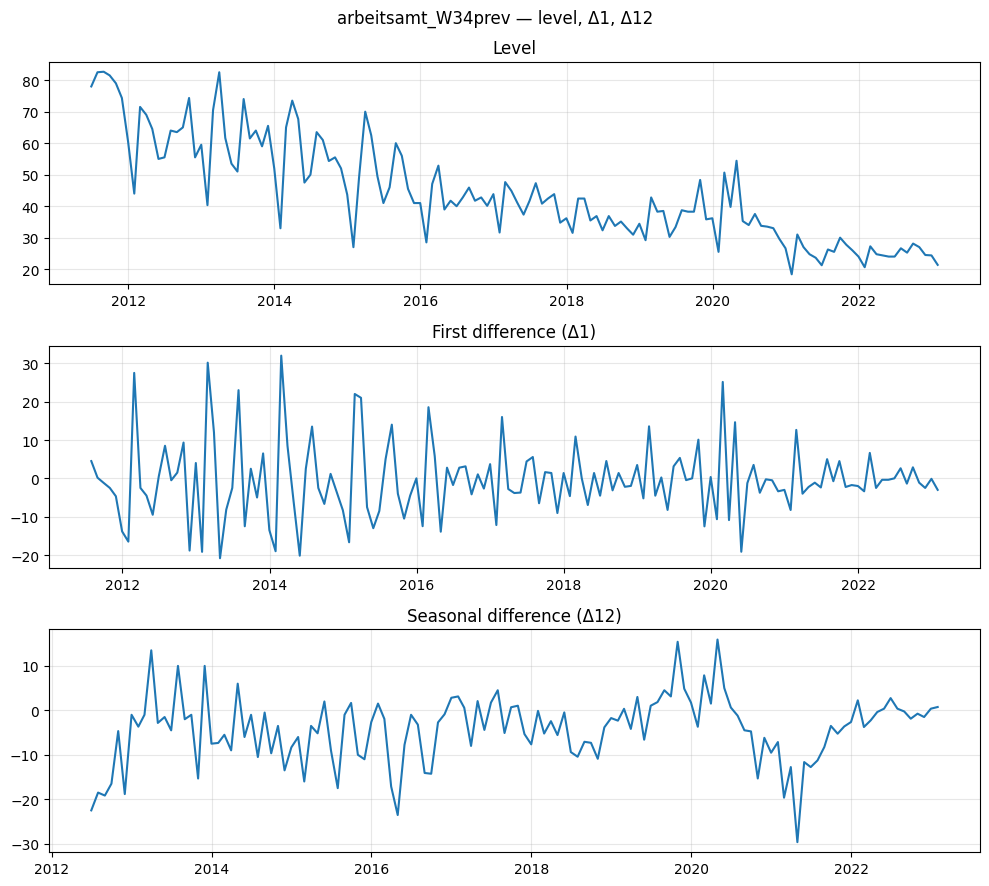

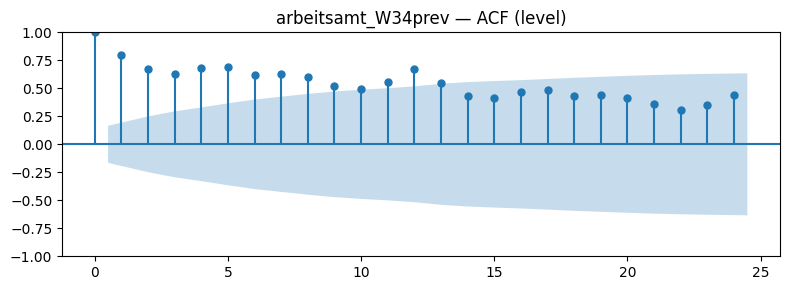

            series transform reg  adf_stat   pvalue  used_lag
arbeitsamt_W34prev     level  nc       NaN      NaN       NaN
arbeitsamt_W34prev     level   c -0.858348 0.801380      13.0
arbeitsamt_W34prev     level  ct -2.310473 0.428166      13.0
arbeitsamt_W34prev     diff1  nc       NaN      NaN       NaN
arbeitsamt_W34prev     diff1   c -4.222609 0.000603      12.0
arbeitsamt_W34prev     diff1  ct -4.206172 0.004382      12.0
arbeitsamt_W34prev    diff12  nc       NaN      NaN       NaN
arbeitsamt_W34prev    diff12   c -3.638448 0.005067      12.0
arbeitsamt_W34prev    diff12  ct -4.482570 0.001612      11.0


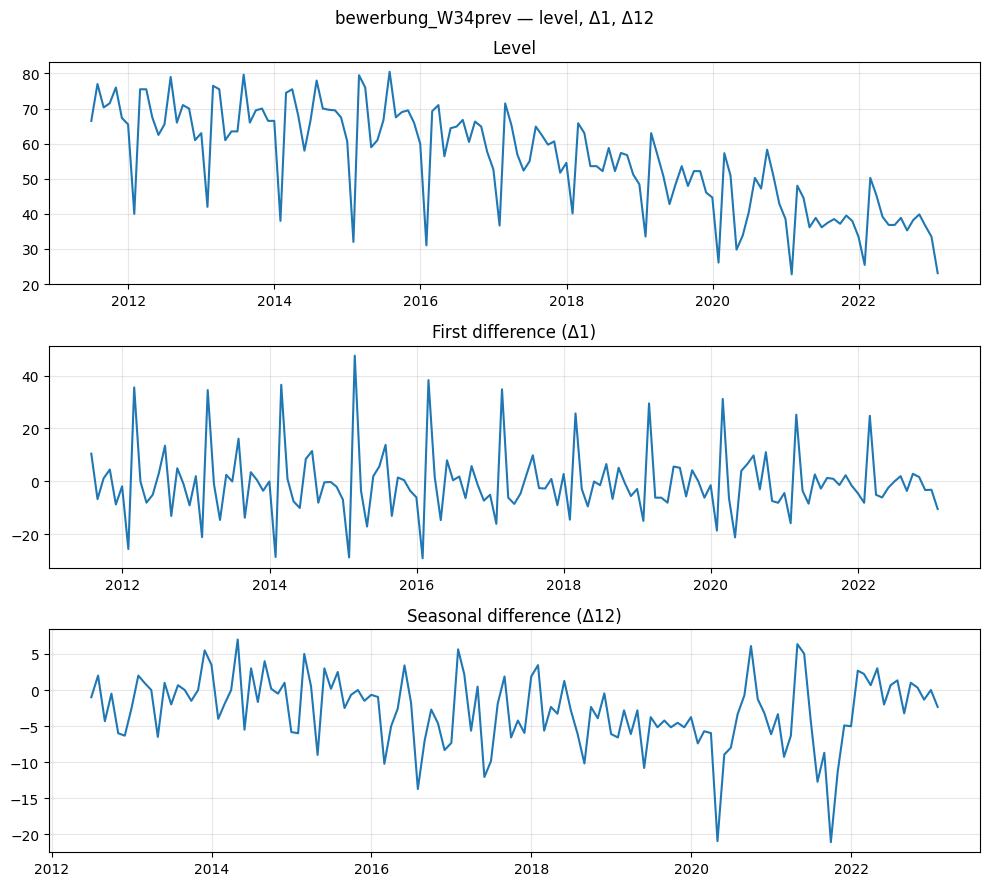

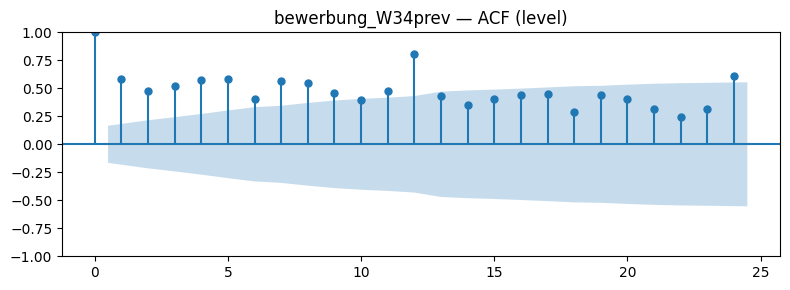

           series transform reg  adf_stat       pvalue  used_lag
bewerbung_W34prev     level  nc       NaN          NaN       NaN
bewerbung_W34prev     level   c  1.013749 9.944089e-01      12.0
bewerbung_W34prev     level  ct -1.943688 6.317417e-01      12.0
bewerbung_W34prev     diff1  nc       NaN          NaN       NaN
bewerbung_W34prev     diff1   c -6.414989 1.850736e-08      11.0
bewerbung_W34prev     diff1  ct -6.654799 8.398633e-08      11.0
bewerbung_W34prev    diff12  nc       NaN          NaN       NaN
bewerbung_W34prev    diff12   c -2.366401 1.514449e-01      12.0
bewerbung_W34prev    diff12  ct -3.841940 1.455412e-02      11.0


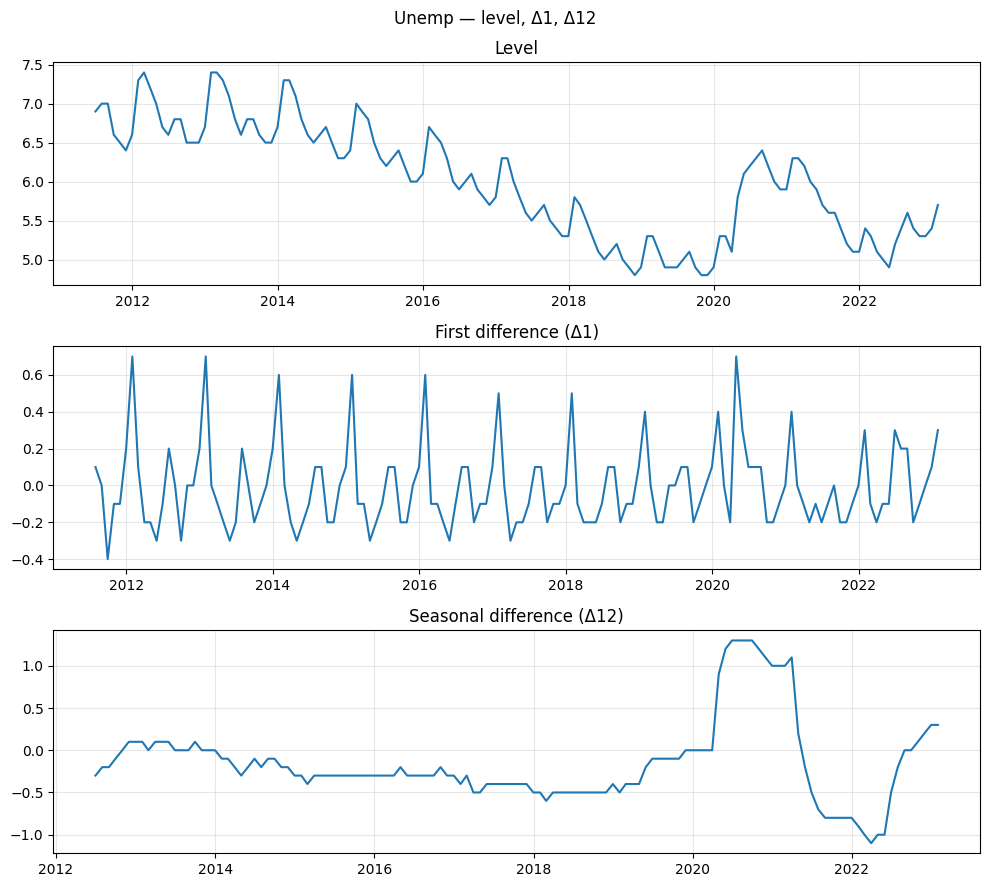

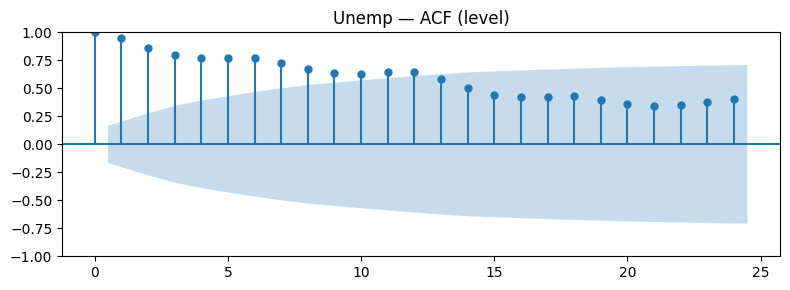

series transform reg  adf_stat   pvalue  used_lag
 Unemp     level  nc       NaN      NaN       NaN
 Unemp     level   c -1.467681 0.549434      14.0
 Unemp     level  ct -2.200938 0.489322      14.0
 Unemp     diff1  nc       NaN      NaN       NaN
 Unemp     diff1   c -2.879761 0.047753      13.0
 Unemp     diff1  ct -2.882821 0.168188      13.0
 Unemp    diff12  nc       NaN      NaN       NaN
 Unemp    diff12   c -2.449291 0.128305      12.0
 Unemp    diff12  ct -2.576972 0.290605      12.0

Stationary at level under any spec (p < 0.05):
      series reg   pvalue  used_lag
jobbörse_W12  ct 0.005386      14.0


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

# ----------------- Helper: run ADF under several specs -----------------
def adf_all(y, name, maxlag=None, min_len=20):
    """
    Run ADF with regressions: no-const (nc), const (c), trend (ct) on:
    - level
    - first difference (Δ1)
    - seasonal difference (Δ12)
    Returns a tidy DataFrame. Skips if too short.
    """
    y = pd.Series(y, copy=False).dropna()
    cols = ["series", "transform", "reg", "adf_stat", "pvalue", "used_lag"]
    out = []

    def run_one(series, transform_label):
        if len(series) < min_len:
            for reg in ("nc", "c", "ct"):
                out.append((name, transform_label, reg, np.nan, np.nan, np.nan))
            return
        for reg in ("nc", "c", "ct"):
            try:
                stat, p, usedlag, nobs, crit, icbest = adfuller(
                    series,
                    regression=reg,
                    autolag="AIC" if maxlag is None else None,
                    maxlag=maxlag,
                )
                out.append((name, transform_label, reg, stat, p, usedlag))
            except Exception:
                out.append((name, transform_label, reg, np.nan, np.nan, np.nan))

    # Level
    run_one(y, "level")
    # Δ1
    run_one(y.diff().dropna(), "diff1")
    # Δ12 (seasonal difference for monthly data)
    run_one(y.diff(12).dropna(), "diff12")

    return pd.DataFrame(out, columns=cols)

# ----------------- Main loop: plots + ADF per column -----------------
summary = []

# If your working DataFrame is 'panel_ecm', switch below from panel -> panel_ecm
for col in panel.columns:
    s = pd.to_numeric(panel[col], errors="coerce")

    # --- Figure with 3 panels: level, Δ1, Δ12 ---
    fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=False)
    fig.suptitle(f"{col} — level, Δ1, Δ12", y=0.98)

    s_level = s.dropna()
    if not s_level.empty:
        axes[0].plot(s_level.index, s_level.values)
    axes[0].set_title("Level")
    axes[0].grid(True, alpha=0.3)

    d1 = s.diff().dropna()
    if not d1.empty:
        axes[1].plot(d1.index, d1.values)
    axes[1].set_title("First difference (Δ1)")
    axes[1].grid(True, alpha=0.3)

    d12 = s.diff(12).dropna()
    if not d12.empty:
        axes[2].plot(d12.index, d12.values)
    axes[2].set_title("Seasonal difference (Δ12)")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Optional ACF (guard for length)
    vals = s.dropna()
    if len(vals) > 24:
        fig2, ax2 = plt.subplots(figsize=(8, 3))
        plot_acf(vals, ax=ax2, lags=24)
        ax2.set_title(f"{col} — ACF (level)")
        plt.tight_layout()
        plt.show()

    # ADF summary table for this column
    res = adf_all(s, col, maxlag=None, min_len=20)
    print(res.to_string(index=False))
    summary.append(res)

# ----------------- Overall ADF summary -----------------
adf_summary = pd.concat(summary, ignore_index=True)

print("\nStationary at level under any spec (p < 0.05):")
stationary_level = adf_summary.query("transform=='level' and pvalue < 0.05")[["series", "reg", "pvalue", "used_lag"]]
print(stationary_level.to_string(index=False))


In [11]:
# calculate the means one sec
# --- Compute descriptive statistics to guide ADF specification
means = panel.mean(numeric_only=True)
stds  = panel.std(numeric_only=True)
stats_df = pd.DataFrame({"mean": means, "std": stds})
stats_df["mean/std ratio"] = stats_df["mean"] / stats_df["std"]
stats_df = stats_df.sort_values("mean")
print(stats_df.round(2))


                     mean    std  mean/std ratio
Unemp                6.00   0.72            8.34
arbeitsamt_W12      43.89  15.67            2.80
arbeitsamt_W34prev  44.30  16.02            2.77
jobbörse_W34prev    50.27  23.82            2.11
jobbörse_W12        52.13  24.17            2.16
bewerbung_W34prev   55.66  14.36            3.88
bewerbung_W12       58.56  13.83            4.24
stepstone_W34prev   61.71  14.01            4.41
stepstone_W12       63.68  13.00            4.90
indeed_W34prev      84.64  39.47            2.14
indeed_W12          87.77  39.97            2.20


In [12]:
# --- Summary statistics for levels, Δ1, and Δ12 ------------------------
desc_list = []
for col in panel.columns:
    s = pd.to_numeric(panel[col], errors="coerce").dropna()
    if len(s) < 20:
        continue

    d1  = s.diff().dropna()
    d12 = s.diff(12).dropna()

    desc_list.append({
        "series": col,
        "mean_level": s.mean(),
        "std_level": s.std(),
        "mean_diff1": d1.mean(),
        "std_diff1": d1.std(),
        "mean_diff12": d12.mean(),
        "std_diff12": d12.std()
    })

level_stats = pd.DataFrame(desc_list)
level_stats["mean/std (level)"]  = level_stats["mean_level"] / level_stats["std_level"]
level_stats["mean/std (Δ1)"]     = level_stats["mean_diff1"] / level_stats["std_diff1"]
level_stats["mean/std (Δ12)"]    = level_stats["mean_diff12"] / level_stats["std_diff12"]

print(level_stats.round(3))


                series  mean_level  std_level  mean_diff1  std_diff1  \
0        stepstone_W12      63.677     13.003       0.086      7.116   
1           indeed_W12      87.771     39.968       0.858     13.896   
2         jobbörse_W12      52.127     24.175      -0.445      6.698   
3       arbeitsamt_W12      43.887     15.675      -0.340      7.052   
4        bewerbung_W12      58.563     13.827      -0.163      9.610   
5    stepstone_W34prev      61.706     14.006      -0.061     11.706   
6       indeed_W34prev      84.643     39.465       0.454     18.254   
7     jobbörse_W34prev      50.268     23.818      -0.458     10.645   
8   arbeitsamt_W34prev      44.298     16.016      -0.407      9.718   
9    bewerbung_W34prev      55.659     14.357      -0.312     12.813   
10               Unemp       6.002      0.719      -0.009      0.222   

    mean_diff12  std_diff12  mean/std (level)  mean/std (Δ1)  mean/std (Δ12)  
0        -1.482      10.408             4.897          0

In [14]:
from statsmodels.tsa.stattools import adfuller

adf_diff_nc = []
for col in panel.columns:
    s = pd.to_numeric(panel[col], errors="coerce").dropna()
    d1 = s.diff().dropna()
    if len(d1) < 20:
        continue
    stat, p, usedlag, nobs, crit, icbest = adfuller(d1, regression="n", autolag="AIC")
    adf_diff_nc.append({"series": col, "ADF Δ1 (nc)": stat, "pvalue": p, "lag": usedlag})

adf_diff_nc = pd.DataFrame(adf_diff_nc)
print(adf_diff_nc.round(4))


                series  ADF Δ1 (nc)  pvalue  lag
0        stepstone_W12      -3.2242  0.0013   11
1           indeed_W12      -2.4965  0.0121   12
2         jobbörse_W12      -3.0608  0.0022   11
3       arbeitsamt_W12      -5.5334  0.0000   10
4        bewerbung_W12      -3.4875  0.0005   12
5    stepstone_W34prev      -4.0136  0.0001   11
6       indeed_W34prev      -2.4891  0.0124   14
7     jobbörse_W34prev      -2.9936  0.0027   11
8   arbeitsamt_W34prev      -3.6222  0.0003   12
9    bewerbung_W34prev      -5.1217  0.0000   11
10               Unemp      -2.8170  0.0047   13


Every first-differenced series (Δ1) rejects the null of a unit root at conventional levels (all p-values < 0.05, many < 0.01).
That means:

All your variables are stationary in first differences → i.e. the levels are I(1) processes.
Integration order:
All your variables are integrated of order 1, I(1).

Levels → non-stationary

First differences → stationary

Consistency with theory:

Unemployment and Google Trends series both exhibit long-run stochastic trends.

This matches the behavior found in Zimmermann (and almost all macro time series).

Because they’re all I(1), you can test for cointegration between unemployment and one or more Google search indicators.

If cointegrated → build an Error-Correction Model (ECM).

If not → model short-run dynamics in differences only.

# Things that are stationary
Stepstone_w12
Indeed_w12 also stationary
Arbeitsamt_w12
Bewerbung_w12

Stepstine_w34
Indeed_w34
arbeitsamt_w34
jobbörse_w34
bewerbung_w34

In [25]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import coint

# --- choose your I(1) candidates (fix typos to match your real column names) ---
candidates = [
    'stepstone_W34prev',
    'indeed_W34prev',
    'arbeitsamt_W34prev',
    'jobbörse_W34prev',
    'bewerbung_W34prev',
    'stepstone_W12',
    'indeed_W12',
    'arbeitsamt_W12',
    'jobbörse_W12',
    'bewerbung_W12',
]

# keep only columns that actually exist (protect against typos)
candidates = [c for c in candidates if c in panel.columns]

Y = panel['Unemp']

rows = []
for det in [ 'c','ct']:        # intercept only; intercept + linear trend
    for col in candidates:
        df = panel[['Unemp', col]].replace([np.inf, -np.inf], np.nan).dropna()
        if len(df) < 30:
            rows.append({'X_var': col, 'trend': det, 'nobs': len(df),
                         'stat': np.nan, 'pvalue': np.nan})
            continue
        # cap lags for small samples; AIC to pick within the cap
        stat, pval, crit = coint(df['Unemp'], df[col], trend=det, maxlag=6, autolag='AIC')
        rows.append({'X_var': col, 'trend': det, 'nobs': len(df),
                     'stat': stat, 'pvalue': pval})

results = pd.DataFrame(rows).sort_values('pvalue', na_position='last').reset_index(drop=True)

print("Pairwise Engle–Granger (Unemp vs. X) — sorted by p-value")
print(results.to_string(index=False))

print("\nLikely cointegrated at 5% (p < 0.05):")
print(results.query("pvalue < 0.05").to_string(index=False))


Pairwise Engle–Granger (Unemp vs. X) — sorted by p-value
             X_var trend  nobs      stat   pvalue
arbeitsamt_W34prev     c   140 -4.600745 0.000832
  jobbörse_W34prev     c   140 -4.418198 0.001664
    arbeitsamt_W12     c   140 -3.107395 0.086827
        indeed_W12     c   140 -2.846376 0.151374
     stepstone_W12     c   140 -2.813709 0.161362
    indeed_W34prev    ct   140 -3.239923 0.171453
 bewerbung_W34prev    ct   140 -2.969759 0.277079
        indeed_W12    ct   140 -2.894558 0.311831
    indeed_W34prev     c   140 -2.427392 0.311994
 stepstone_W34prev    ct   140 -2.869985 0.323657
 stepstone_W34prev     c   140 -2.339426 0.354053
  jobbörse_W34prev    ct   140 -2.785911 0.365682
      jobbörse_W12     c   140 -2.304360 0.371379
     stepstone_W12    ct   140 -2.697110 0.412274
     bewerbung_W12    ct   140 -2.683201 0.419735
    arbeitsamt_W12    ct   140 -2.670996 0.426312
arbeitsamt_W34prev    ct   140 -2.666011 0.429006
      jobbörse_W12    ct   140 -2.582467 0.


=== ARBEITSAMT_W34PREV ===
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  4.6563      0.133     35.128      0.000       4.394       4.918
arbeitsamt_W34prev     0.0304      0.003     10.793      0.000       0.025       0.036


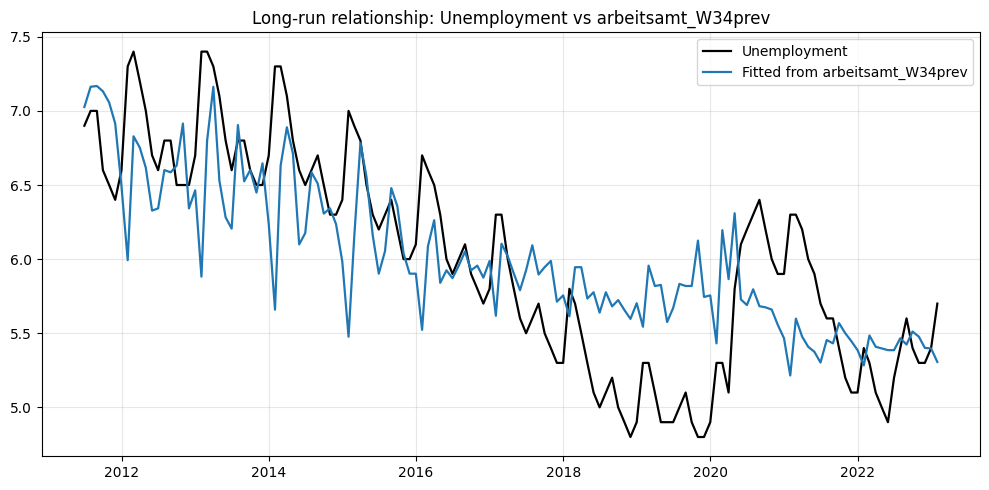

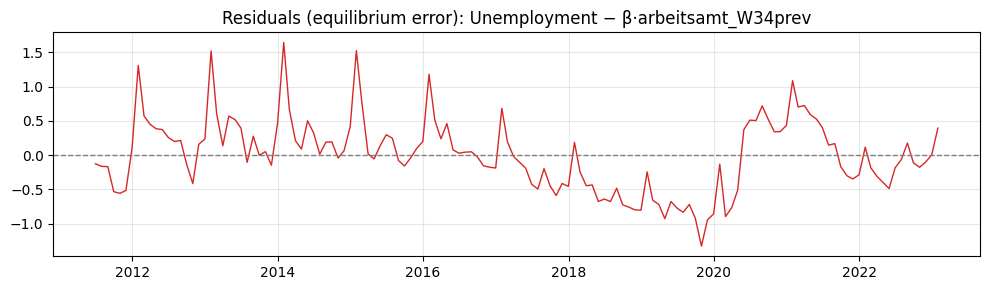


=== JOBBÖRSE_W34PREV ===
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                4.9261      0.101     48.873      0.000       4.727       5.125
jobbörse_W34prev     0.0214      0.002     11.806      0.000       0.018       0.025


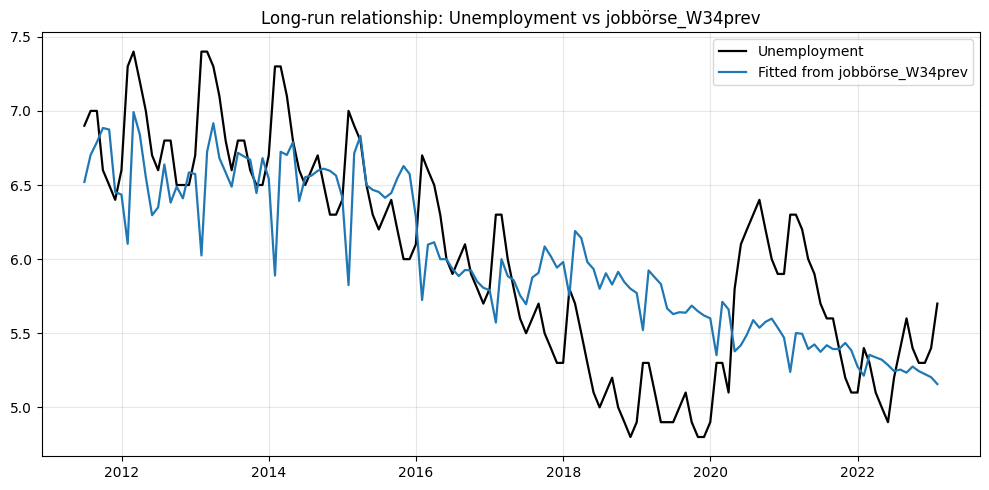

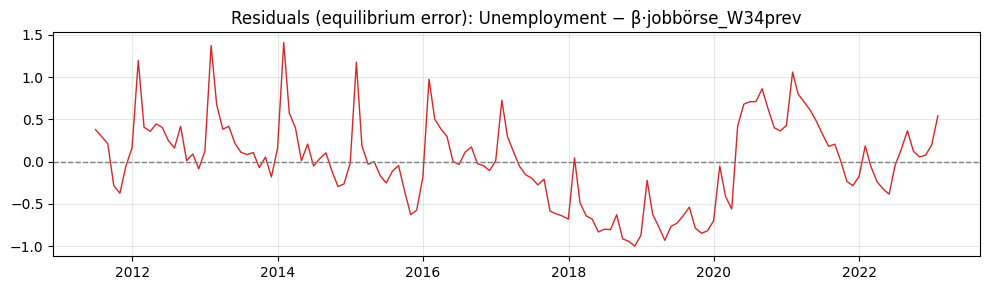

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# --- Define your cointegrated pairs (from your test results)
cointegrated_pairs = ['arbeitsamt_W34prev', 'jobbörse_W34prev']

Y = panel['Unemp']

for col in cointegrated_pairs:
    df = panel[['Unemp', col]].dropna()
    X = sm.add_constant(df[col])  # include intercept, since trend='c' was significant

    model = sm.OLS(df['Unemp'], X).fit()
    df['fitted'] = model.fittedvalues
    df['resid'] = model.resid

    print(f"\n=== {col.upper()} ===")
    print(model.summary().tables[1])

    # --- Plot 1: Levels (Unemp and fitted relationship)
    plt.figure(figsize=(10, 5))
    plt.plot(df.index, df['Unemp'], label='Unemployment', color='black', linewidth=1.6)
    plt.plot(df.index, df['fitted'], label=f'Fitted from {col}', color='tab:blue', linewidth=1.6)
    plt.title(f'Long-run relationship: Unemployment vs {col}')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Plot 2: Residuals (error correction term)
    plt.figure(figsize=(10, 3))
    plt.plot(df.index, df['resid'], color='tab:red', linewidth=1)
    plt.axhline(0, color='gray', linestyle='--', linewidth=1)
    plt.title(f'Residuals (equilibrium error): Unemployment − β·{col}')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


,Unemp,bewerbung_W12
Date,,
2011-06-30,6.9,69.5
2011-07-31,7.0,86.5
2011-08-31,7.0,73.0
2011-09-30,6.6,73.5
2011-10-31,6.5,71.0


# Johansen Test

In [16]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# Suppose df has the I(1) variables: Unemp, Arbeitsamt_W34prev, Jobbörse_W34prev
cols = ['Unemp', 'arbeitsamt_W34prev', 'jobbörse_W34prev']
result = coint_johansen(panel[cols], det_order=0, k_ar_diff=2)

# Johansen test output
print(result.lr1)      # Trace statistics
print(result.cvt)      # Critical values (90%, 95%, 99%)


[39.72076331 11.18611266  1.8026722 ]
[[27.0669 29.7961 35.4628]
 [13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]


# Neuer test heute

In [30]:
import pandas as pd
import statsmodels.api as sm

df = panel[['Unemp','arbeitsamt_W34prev']].dropna().copy()

# 1) Cointegrating regression (levels)
X_coint = sm.add_constant(df['arbeitsamt_W34prev'].astype(float))
coint_mod = sm.OLS(df['Unemp'].astype(float), X_coint).fit()
df['ecm_resid'] = coint_mod.resid

# 2) Differences and lagged residual
df['dUnemp'] = df['Unemp'].astype(float).diff()
df['dArbeitsamt'] = df['arbeitsamt_W34prev'].astype(float).diff()
df['ecm_resid_lag'] = df['ecm_resid'].shift(1)

# 3) Monthly dummies (force float)
dummies = pd.get_dummies(df.index.month, prefix='m', drop_first=True).astype(float)
dummies.index = df.index
df = pd.concat([df, dummies], axis=1)

# 4) Assemble ECM data
ecm_df = df.dropna().copy()
exog_cols = ['ecm_resid_lag','dArbeitsamt'] + list(dummies.columns)
X = sm.add_constant(ecm_df[exog_cols].astype(float))
y = ecm_df['dUnemp'].astype(float)

# Sanity check
print("Dtypes:\n", pd.concat([y, X], axis=1).dtypes)

# 5) Fit ECM with HAC SEs (robust for autocorrelation)
ecm = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags':12})
print(ecm.summary())


Dtypes:
 dUnemp           float64
const            float64
ecm_resid_lag    float64
dArbeitsamt      float64
m_2              float64
m_3              float64
m_4              float64
m_5              float64
m_6              float64
m_7              float64
m_8              float64
m_9              float64
m_10             float64
m_11             float64
m_12             float64
dtype: object
                            OLS Regression Results                            
Dep. Variable:                 dUnemp   R-squared:                       0.736
Model:                            OLS   Adj. R-squared:                  0.709
Method:                 Least Squares   F-statistic:                     86.96
Date:                Sat, 01 Nov 2025   Prob (F-statistic):           4.73e-56
Time:                        17:19:59   Log-Likelihood:                 105.08
No. Observations:                 139   AIC:                            -182.2
Df Residuals:                     125   BIC:     

In [31]:
import pandas as pd
import statsmodels.api as sm

# --- 1) Prepare data
df = panel[['Unemp', 'jobbörse_W34prev']].dropna().copy()

# --- 2) Cointegrating regression (levels)
X_coint = sm.add_constant(df['jobbörse_W34prev'].astype(float))
coint_mod = sm.OLS(df['Unemp'].astype(float), X_coint).fit()
df['ecm_resid'] = coint_mod.resid

# --- 3) Build first differences and lagged residual
df['dUnemp'] = df['Unemp'].astype(float).diff()
df['dJobboerse'] = df['jobbörse_W34prev'].astype(float).diff()
df['ecm_resid_lag'] = df['ecm_resid'].shift(1)

# --- 4) Monthly dummies (float)
dummies = pd.get_dummies(df.index.month, prefix='m', drop_first=True).astype(float)
dummies.index = df.index
df = pd.concat([df, dummies], axis=1)

# --- 5) ECM dataset
ecm_df = df.dropna().copy()
exog_cols = ['ecm_resid_lag', 'dJobboerse'] + list(dummies.columns)
X = sm.add_constant(ecm_df[exog_cols].astype(float))
y = ecm_df['dUnemp'].astype(float)

# --- 6) Fit ECM with HAC(12) SEs
ecm_job = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 12})
print(ecm_job.summary())


                            OLS Regression Results                            
Dep. Variable:                 dUnemp   R-squared:                       0.725
Model:                            OLS   Adj. R-squared:                  0.697
Method:                 Least Squares   F-statistic:                     85.11
Date:                Sat, 01 Nov 2025   Prob (F-statistic):           1.56e-55
Time:                        17:23:15   Log-Likelihood:                 102.20
No. Observations:                 139   AIC:                            -176.4
Df Residuals:                     125   BIC:                            -135.3
Df Model:                          13                                         
Covariance Type:                  HAC                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.4844      0.058      8.342

In [33]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# ---------- 1) Prepare series ----------
xcol = 'arbeitsamt_W34prev'   # <-- match exactly (umlaut/underscore)
df = panel[['Unemp', xcol]].dropna().copy()

# Cointegrating regression (levels, with intercept)
Xc = sm.add_constant(df[xcol].astype(float))
cmod = sm.OLS(df['Unemp'].astype(float), Xc).fit()
df['ecm_resid'] = cmod.resid

# Build ECM inputs
df['dUnemp'] = df['Unemp'].astype(float).diff()
df['dX'] = df[xcol].astype(float).diff()
df['ecm_resid_lag'] = df['ecm_resid'].shift(1)

# Monthly dummies
dummies = pd.get_dummies(df.index.month, prefix='m', drop_first=True).astype(float)
dummies.index = df.index
df = pd.concat([df, dummies], axis=1).dropna()

# ---------- 2) Fit ECM with HAC(12) ----------
exog_cols = ['ecm_resid_lag','dX'] + [c for c in df.columns if c.startswith('m_')]
X = sm.add_constant(df[exog_cols].astype(float))
y = df['dUnemp'].astype(float)

ecm_arb = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags':12})
print(ecm_arb.summary())

# ---------- 3) One-step nowcast ----------
# Last available (t): need e_{t-1}, dX_t, and month dummies for (t)
ecm_resid_lag = cmod.resid.iloc[-1]                      # e_{t-1}
dX_t = df[xcol].iloc[-1] - df[xcol].iloc[-2]             # ΔX_t (same as df['dX'].iloc[-1])

# Build a single-row exog matching ECM columns
month_t = df.index[-1].month
row = {'const': 1.0, 'ecm_resid_lag': float(ecm_resid_lag), 'dX': float(dX_t)}
for col in [c for c in X.columns if c.startswith('m_')]:
    # set the active month dummy = 1, others 0 (remember January is baseline if you dropped first)
    row[col] = 1.0 if col == f"m_{month_t}" else 0.0

X_now = pd.DataFrame([row], columns=X.columns)
pred_dUnemp = float(ecm_arb.predict(X_now))

Unemp_nowcast_arb = panel['Unemp'].iloc[-1] + pred_dUnemp
print("Nowcast (Arbeitsamt ECM):", round(Unemp_nowcast_arb, 3))


                            OLS Regression Results                            
Dep. Variable:                 dUnemp   R-squared:                       0.736
Model:                            OLS   Adj. R-squared:                  0.709
Method:                 Least Squares   F-statistic:                     86.96
Date:                Sat, 01 Nov 2025   Prob (F-statistic):           4.73e-56
Time:                        17:26:43   Log-Likelihood:                 105.08
No. Observations:                 139   AIC:                            -182.2
Df Residuals:                     125   BIC:                            -141.1
Df Model:                          13                                         
Covariance Type:                  HAC                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.5293      0.051     10.398

/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_23653/2699110797.py:45: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred_dUnemp = float(ecm_arb.predict(X_now))


In [34]:
# ---------- 1) Prepare series ----------
xcol = 'jobbörse_W34prev'     # <-- exact column name with umlaut
df = panel[['Unemp', xcol]].dropna().copy()

# Cointegrating regression
Xc = sm.add_constant(df[xcol].astype(float))
cmod = sm.OLS(df['Unemp'].astype(float), Xc).fit()
df['ecm_resid'] = cmod.resid

# ECM inputs
df['dUnemp'] = df['Unemp'].astype(float).diff()
df['dX'] = df[xcol].astype(float).diff()
df['ecm_resid_lag'] = df['ecm_resid'].shift(1)

# Monthly dummies
dummies = pd.get_dummies(df.index.month, prefix='m', drop_first=True).astype(float)
dummies.index = df.index
df = pd.concat([df, dummies], axis=1).dropna()

# ---------- 2) Fit ECM ----------
exog_cols = ['ecm_resid_lag','dX'] + [c for c in df.columns if c.startswith('m_')]
X = sm.add_constant(df[exog_cols].astype(float))
y = df['dUnemp'].astype(float)

ecm_job = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags':12})
print(ecm_job.summary())

# ---------- 3) One-step nowcast ----------
ecm_resid_lag = cmod.resid.iloc[-1]
dX_t = df[xcol].iloc[-1] - df[xcol].iloc[-2]

month_t = df.index[-1].month
row = {'const': 1.0, 'ecm_resid_lag': float(ecm_resid_lag), 'dX': float(dX_t)}
for col in [c for c in X.columns if c.startswith('m_')]:
    row[col] = 1.0 if col == f"m_{month_t}" else 0.0

X_now = pd.DataFrame([row], columns=X.columns)
pred_dUnemp = float(ecm_job.predict(X_now))

Unemp_nowcast_job = panel['Unemp'].iloc[-1] + pred_dUnemp
print("Nowcast (Jobbörse ECM):", round(Unemp_nowcast_job, 3))


                            OLS Regression Results                            
Dep. Variable:                 dUnemp   R-squared:                       0.725
Model:                            OLS   Adj. R-squared:                  0.697
Method:                 Least Squares   F-statistic:                     85.11
Date:                Sat, 01 Nov 2025   Prob (F-statistic):           1.56e-55
Time:                        17:27:02   Log-Likelihood:                 102.20
No. Observations:                 139   AIC:                            -176.4
Df Residuals:                     125   BIC:                            -135.3
Df Model:                          13                                         
Covariance Type:                  HAC                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.4844      0.058      8.342

/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_23653/4013216924.py:38: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred_dUnemp = float(ecm_job.predict(X_now))


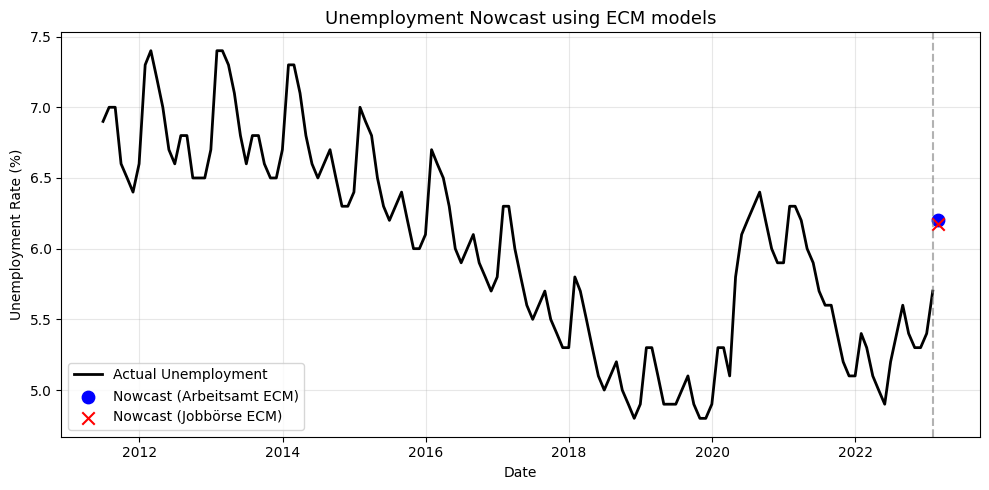

In [35]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(10,5))

# Plot actual unemployment
plt.plot(panel['Unemp'], label='Actual Unemployment', color='black', linewidth=2)

# Mark the nowcast date (one month ahead)
nowcast_date = panel.index[-1] + pd.offsets.MonthEnd(1)

plt.scatter(nowcast_date, Unemp_nowcast_arb, color='blue', label='Nowcast (Arbeitsamt ECM)', s=80, marker='o')
plt.scatter(nowcast_date, Unemp_nowcast_job, color='red', label='Nowcast (Jobbörse ECM)', s=80, marker='x')

plt.axvline(panel.index[-1], color='grey', linestyle='--', alpha=0.6)
plt.title("Unemployment Nowcast using ECM models", fontsize=13)
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_23653/3494625640.py:54: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  dUnemp_nowcast = float(ecm.predict(X_now))


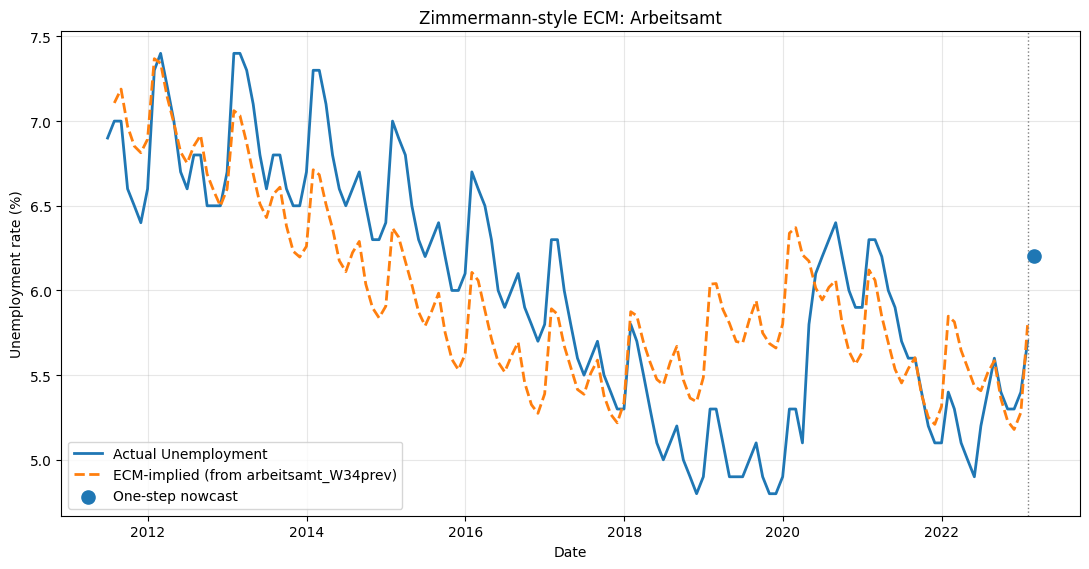

/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_23653/3494625640.py:54: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  dUnemp_nowcast = float(ecm.predict(X_now))


Nowcast (Arbeitsamt): 6.202 @ 2023-02-28


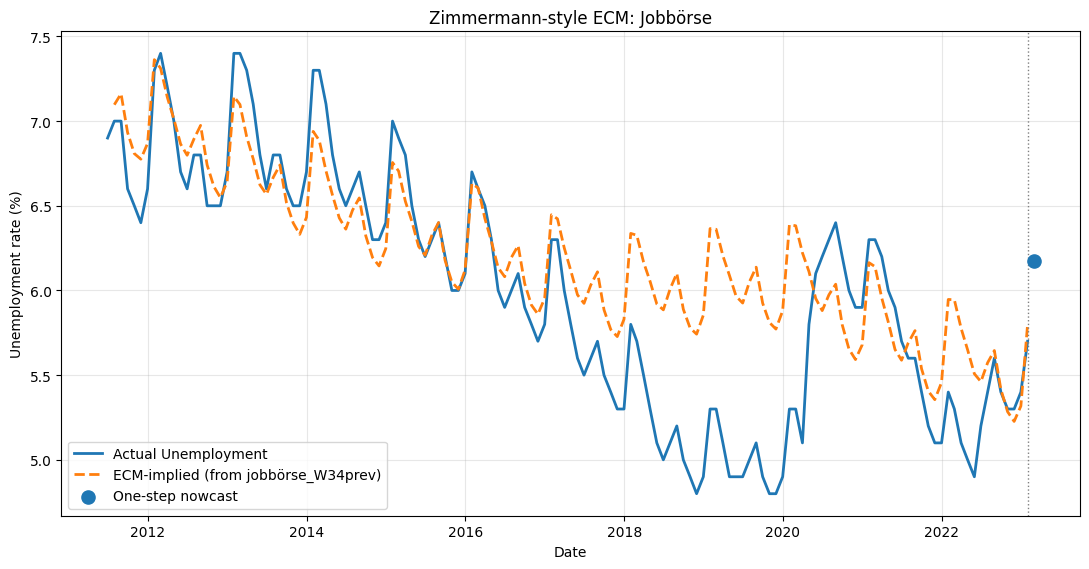

Nowcast (Jobbörse): 6.176 @ 2023-02-28


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

def plot_zimmer_style_ecm(panel, xcol, title=None):
    """
    Build Zimmermann-style chart:
      - Actual Unemployment (levels)
      - ECM-implied unemployment (levels) = Unemp_start + cumsum(fitted ΔUnemp)
      - One-step nowcast point for next month
    """
    # ---------- 1) Prepare data for chosen X ----------
    df = panel[['Unemp', xcol]].dropna().copy()
    # Cointegrating regression (levels, intercept)
    Xc = sm.add_constant(df[xcol].astype(float))
    cmod = sm.OLS(df['Unemp'].astype(float), Xc).fit()
    df['ecm_resid'] = cmod.resid

    # ECM inputs
    df['dUnemp'] = df['Unemp'].astype(float).diff()
    df['dX'] = df[xcol].astype(float).diff()
    df['ecm_resid_lag'] = df['ecm_resid'].shift(1)
    # Monthly dummies (Jan baseline)
    dummies = pd.get_dummies(df.index.month, prefix='m', drop_first=True).astype(float)
    dummies.index = df.index
    df = pd.concat([df, dummies], axis=1).dropna()

    # ---------- 2) Fit ECM (HAC SEs for monthly) ----------
    exog_cols = ['ecm_resid_lag', 'dX'] + [c for c in df.columns if c.startswith('m_')]
    X = sm.add_constant(df[exog_cols].astype(float))
    y = df['dUnemp'].astype(float)
    ecm = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags':12})

    # ---------- 3) ECM-implied unemployment (levels) ----------
    # In-sample fitted ΔUnemp
    dUnemp_hat = ecm.fittedvalues
    # Align to index of ECM sample
    idx = dUnemp_hat.index
    # Start level = actual Unemp at first ECM obs - so the cumsum overlays properly
    Unemp_start = panel.loc[idx[0], 'Unemp']
    Unemp_hat_level = pd.Series(Unemp_start, index=idx)
    Unemp_hat_level = Unemp_hat_level.add(dUnemp_hat.cumsum())

    # ---------- 4) One-step nowcast (t+1) ----------
    # Build one-row exog for the last observed month t
    ecm_resid_lag_t = cmod.resid.loc[idx[-1]]               # e_{t}
    dX_t = panel[xcol].loc[idx[-1]] - panel[xcol].loc[idx[-2]]  # ΔX_t
    month_t = idx[-1].month
    row = {'const': 1.0, 'ecm_resid_lag': float(ecm_resid_lag_t), 'dX': float(dX_t)}
    for col in [c for c in X.columns if c.startswith('m_')]:
        row[col] = 1.0 if col == f"m_{month_t}" else 0.0
    X_now = pd.DataFrame([row], columns=X.columns)
    dUnemp_nowcast = float(ecm.predict(X_now))
    # Next month timestamp (month-end to match your index style)
    next_date = idx[-1] + pd.offsets.MonthEnd(1)
    Unemp_nowcast = panel['Unemp'].loc[idx[-1]] + dUnemp_nowcast

    # ---------- 5) Plot (Zimmermann-style) ----------
    plt.figure(figsize=(11,5.8))

    # Actual line
    plt.plot(panel['Unemp'], label='Actual Unemployment', linewidth=2)

    # ECM-implied in-sample line
    plt.plot(Unemp_hat_level, label=f'ECM-implied (from {xcol})', linewidth=2, linestyle='--')

    # Nowcast point
    plt.scatter(next_date, Unemp_nowcast, s=90, marker='o', label='One-step nowcast', zorder=5)

    # Vertical line at last observed
    plt.axvline(idx[-1], color='gray', linestyle=':', linewidth=1)

    # Title / labels
    if title is None:
        title = f"Unemployment: Actual vs ECM-implied and Nowcast ({xcol})"
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Unemployment rate (%)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Optional: return objects if you want to reuse values
    return {
        'coint_model': cmod,
        'ecm': ecm,
        'ecm_implied_level': Unemp_hat_level,
        'nowcast_date': next_date,
        'nowcast_unemp': Unemp_nowcast
    }

# ===== Example calls =====
# Arbeitsamt version
out_arb = plot_zimmer_style_ecm(panel, 'arbeitsamt_W34prev', title="Zimmermann-style ECM: Arbeitsamt")
print("Nowcast (Arbeitsamt):", round(out_arb['nowcast_unemp'], 3), "@", out_arb['nowcast_date'].date())

# Jobbörse version
out_job = plot_zimmer_style_ecm(panel, 'jobbörse_W34prev', title="Zimmermann-style ECM: Jobbörse")
print("Nowcast (Jobbörse):", round(out_job['nowcast_unemp'], 3), "@", out_job['nowcast_date'].date())


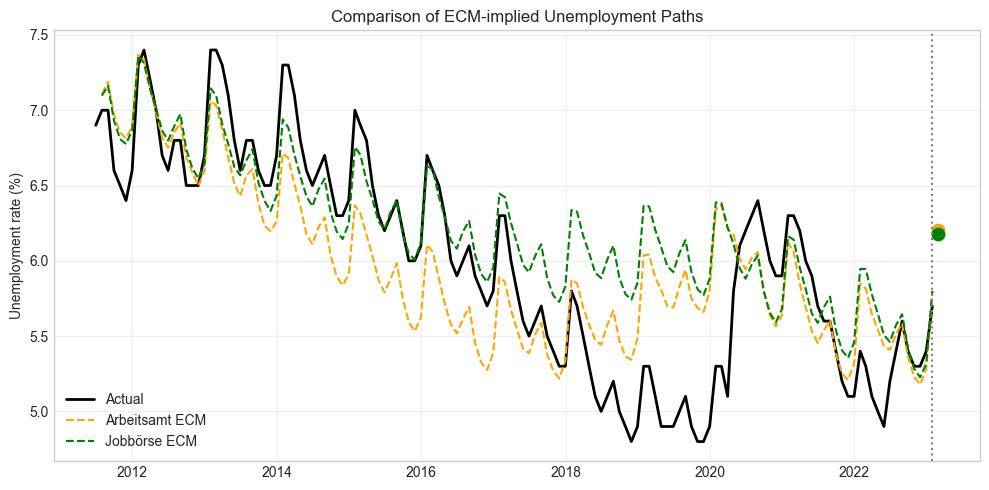

In [38]:
plt.figure(figsize=(10,5))
plt.plot(panel['Unemp'], label='Actual', color='black', linewidth=2)
plt.plot(out_arb['ecm_implied_level'], '--', label='Arbeitsamt ECM', color='orange')
plt.plot(out_job['ecm_implied_level'], '--', label='Jobbörse ECM', color='green')
plt.scatter(out_arb['nowcast_date'], out_arb['nowcast_unemp'], color='orange', s=80)
plt.scatter(out_job['nowcast_date'], out_job['nowcast_unemp'], color='green', s=80)
plt.axvline(panel.index[-1], color='gray', linestyle=':')
plt.legend()
plt.title('Comparison of ECM-implied Unemployment Paths')
plt.ylabel('Unemployment rate (%)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Cointegration modeling

In [26]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
import matplotlib.pyplot as plt

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 200)




In [20]:
# ---- EXPECTED: 'panel' already exists from your previous code ----
# Columns example: ['stepstone_W34prev','indeed_W34prev','arbeitsamt_W34prev','jobborse_W34prev','bewerbung_W34prev',
#                   'stepstone_W12', ... , 'Unemp']

panel_ecm = panel.copy()
# Normalize ALL column names to ASCII: ö→oe, ä→ae, ü→ue, ß→ss
def normalize_cols(df):
    new_cols = {}
    for c in df.columns:
        c2 = (c.replace("ö","oe")
               .replace("ä","ae")
               .replace("ü","ue")
               .replace("ß","ss"))
        new_cols[c] = c2
    return df.rename(columns=new_cols)

panel_ecm = normalize_cols(panel_ecm)

print("✅ Normalized columns:")
print(panel_ecm.columns.tolist())


# Standardize non-ascii 'jobbörse' -> 'jobborse' etc.
rename_map = {c: c.replace("ö","oe").replace("ä","ae").replace("ü","ue").replace("ß","ss") for c in panel_ecm.columns}
panel_ecm.rename(columns=rename_map, inplace=True)

# Sanity: confirm required columns exist
req_cols = ["Unemp", "arbeitsamt_W34prev", "jobborse_W34prev"]
missing = [c for c in req_cols if c not in panel_ecm.columns]
print("Missing core columns:", missing)

# Ensure a proper monthly DateTimeIndex (month-end labels)
if not isinstance(panel_ecm.index, pd.DatetimeIndex):
    # If your 'Date' is a column, do:
    # panel_ecm = panel_ecm.set_index('Date')
    raise ValueError("panel must have a DateTimeIndex (month-end). Set it before proceeding.")

print("Panel shape:", panel_ecm.shape)
print(panel_ecm.tail(3))


✅ Normalized columns:
['stepstone_W12', 'indeed_W12', 'jobboerse_W12', 'arbeitsamt_W12', 'bewerbung_W12', 'stepstone_W34prev', 'indeed_W34prev', 'jobboerse_W34prev', 'arbeitsamt_W34prev', 'bewerbung_W34prev', 'Unemp']
Missing core columns: ['jobborse_W34prev']
Panel shape: (140, 11)
            stepstone_W12  indeed_W12  jobboerse_W12  arbeitsamt_W12  bewerbung_W12  stepstone_W34prev  indeed_W34prev  jobboerse_W34prev  \
Date                                                                                                                                        
2022-11-30      55.121024  131.931723      14.634072       24.018307      38.857836          55.490964      127.595938          13.914364   
2022-12-31      46.982349  105.917017      12.235044       23.643021      32.158209          51.421627      113.349790          12.954753   
2023-01-31      61.410000  133.789916      17.592874       29.272311      46.897388          38.473735       77.115021          10.795627   

          

In [24]:
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint

# --- 0) Start from panel_ecm = panel.copy() and normalize ONCE earlier (you already did) ---

print("\nColumns present:")
print(panel_ecm.columns.tolist())

# --- 1) Helper (unchanged) ---
def estimate_cointegration_ec_term(df, yname, xname, trend='c', maxlag=6):
    """
    Engle–Granger two-step:
      1) OLS levels: y_t = a + b*x_t (+ optional trend) + u_t
      2) EC term = u_t; also print coint test for info
    """
    if xname not in df.columns:
        raise KeyError(f"xname '{xname}' not found. Available: {list(df.columns)}")

    sub = df[[yname, xname]].dropna().copy()
    print(f"\n--- Cointegration test: {yname} ~ {xname} ---")
    print("Sample length:", len(sub))

    # 1) Engle–Granger test
    stat, pval, crit = coint(sub[yname], sub[xname], trend=trend, maxlag=maxlag, autolag='AIC')
    print(f"Engle-Granger: stat={stat:.3f}, p={pval:.4f}, crit={crit}")

    # 2) Cointegrating regression (levels)
    X = sm.add_constant(sub[[xname]])
    if trend == 'ct':
        X['trend'] = np.arange(len(X)) + 1
    ols_fit = sm.OLS(sub[yname], X).fit()
    print("\nCointegrating regression coefficients:")
    print(ols_fit.summary().tables[1])

    sub['ec'] = ols_fit.resid
    # Align EC term back to full index (NaNs where missing)
    ec_full = sub[['ec']].reindex(df.index)
    return ec_full

# --- 2) Use the CORRECT column names (as printed above) ---
Y = 'Unemp'
X_ARB = 'arbeitsamt_W34prev'
X_JOB = 'jobboerse_W34prev'   # <-- NOTE: 'jobboerse', not 'jobborse' and not 'jobbörse'

# Build EC terms
ec_arb = estimate_cointegration_ec_term(panel_ecm, Y, X_ARB, trend='c')
ec_job = estimate_cointegration_ec_term(panel_ecm, Y, X_JOB, trend='c')

# Store EC terms using ASCII-safe names
panel_ecm['EC_arbeitsamt'] = ec_arb['ec']
panel_ecm['EC_jobboerse']  = ec_job['ec']

print("\nTail with EC terms (sanity check):")
print(panel_ecm[[Y, X_ARB, X_JOB, 'EC_arbeitsamt', 'EC_jobboerse']].tail(5))



Columns present:
['stepstone_W12', 'indeed_W12', 'jobboerse_W12', 'arbeitsamt_W12', 'bewerbung_W12', 'stepstone_W34prev', 'indeed_W34prev', 'jobboerse_W34prev', 'arbeitsamt_W34prev', 'bewerbung_W34prev', 'Unemp', 'month']

--- Cointegration test: Unemp ~ arbeitsamt_W34prev ---
Sample length: 140
Engle-Granger: stat=-4.601, p=0.0008, crit=[-3.97696591 -3.38044069 -3.07510301]

Cointegrating regression coefficients:
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  4.6563      0.133     35.128      0.000       4.394       4.918
arbeitsamt_W34prev     0.0304      0.003     10.793      0.000       0.025       0.036

--- Cointegration test: Unemp ~ jobboerse_W34prev ---
Sample length: 140
Engle-Granger: stat=-4.418, p=0.0017, crit=[-3.97696591 -3.38044069 -3.07510301]

Cointegrating regression coefficients:
                        coef    std er

| Variable             | ADF stat | p-value | Critical 5% | Conclusion                     |
| -------------------- | -------- | ------- | ----------- | ------------------------------ |
| `arbeitsamt_W34prev` | -4.601   | 0.0008  | -3.38       | ✅ Reject H₀ → **cointegrated** |
| `jobboerse_W34prev`  | -4.418   | 0.0017  | -3.38       | ✅ Reject H₀ → **cointegrated** |


There is a long-run equilibrium relationship between unemployment and both of these Google Trends indicators:

arbeitsamt_W34prev (searches for “Arbeitsamt”) → inflow indicator → positively related to unemployment.

jobboerse_W34prev (searches for “Jobbörse”) → outflow indicator → also positively related, but you’ll interpret the sign in the short-run model.

In [26]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# ---------- SAFETY HELPERS ----------
def _to_float_df(df):
    """Coerce all columns to float, replacing inf with NaN."""
    out = df.copy()
    for c in out.columns:
        out[c] = pd.to_numeric(out[c], errors='coerce')
    out = out.replace([np.inf, -np.inf], np.nan)
    return out

def _ensure_month_col(df):
    """Ensure an integer month column exists."""
    if 'month' not in df.columns:
        if isinstance(df.index, pd.DatetimeIndex):
            df = df.copy()
            df['month'] = df.index.month
        else:
            raise ValueError("No 'month' column and index is not DatetimeIndex.")
    return df

# ---------- ROBUST ECM WITH DUMMIES ----------
def build_ecm_with_month_dummies_SAFE(df, yname, xname, ec_name, add_month_dummies=True):
    # 0) ensure required cols exist
    for col in [yname, xname, ec_name]:
        if col not in df.columns:
            raise KeyError(f"Missing column '{col}'. Available: {list(df.columns)}")

    d = df[[yname, xname, ec_name]].copy()
    d = _ensure_month_col(d.join(df[['month']] if 'month' in df.columns else pd.Series(index=df.index)))
    
    # 1) short-run transformations
    d['dY']    = pd.to_numeric(d[yname], errors='coerce').diff(1)
    d['dX']    = pd.to_numeric(d[xname], errors='coerce').diff(1)
    d['dY_l1'] = d['dY'].shift(1)
    d['dX_l1'] = d['dX'].shift(1)
    d['EC_l1'] = pd.to_numeric(d[ec_name], errors='coerce').shift(1)

    # 2) month dummies
    Xcols = ['dY_l1','dX','dX_l1','EC_l1']
    if add_month_dummies:
        md = pd.get_dummies(d['month'].astype(int), prefix='m', drop_first=True)
        d = pd.concat([d, md], axis=1)
        Xcols += list(md.columns)

    # 3) build model frame (Y, X), coerce to float, drop NaN
    model_df = d[['dY'] + Xcols].copy()
    model_df = _to_float_df(model_df)
    model_df = model_df.dropna()

    # 4) construct matrices
    Y = model_df['dY'].astype(float)
    X = sm.add_constant(model_df[Xcols].astype(float), has_constant='add')

    # prints for debugging
    print(f"\n--- ECM SAFE: {yname} ~ {xname} | Obs={len(model_df)} ---")
    print("Regressors:", X.columns.tolist())
    print("\nDtypes:\n", pd.DataFrame({'dtype': X.dtypes.astype(str)}).T)
    print("\nHead(X):\n", X.head(3))
    print("\nHead(Y):\n", Y.head(3))

    if len(model_df) < 30:
        raise ValueError(f"Not enough rows after cleaning: {len(model_df)}")

    # 5) fit OLS with robust SEs
    res = sm.OLS(Y, X).fit(cov_type='HC1')
    print(res.summary())
    return res, model_df

# ---------- CALLS ----------
# Make absolutely sure your base columns are numeric (harmless if already ok)
for col in ['Unemp','arbeitsamt_W34prev','jobboerse_W34prev','EC_arbeitsamt','EC_jobboerse','month']:
    if col in panel_ecm.columns:
        panel_ecm[col] = pd.to_numeric(panel_ecm[col], errors='coerce')

# Run ECMs (with month dummies)
res_arb, df_arb = build_ecm_with_month_dummies_SAFE(
    panel_ecm, 'Unemp', 'arbeitsamt_W34prev', 'EC_arbeitsamt', add_month_dummies=True
)

res_job, df_job = build_ecm_with_month_dummies_SAFE(
    panel_ecm, 'Unemp', 'jobboerse_W34prev', 'EC_jobboerse', add_month_dummies=True
)



--- ECM SAFE: Unemp ~ arbeitsamt_W34prev | Obs=138 ---
Regressors: ['const', 'dY_l1', 'dX', 'dX_l1', 'EC_l1', 'm_2', 'm_3', 'm_4', 'm_5', 'm_6', 'm_7', 'm_8', 'm_9', 'm_10', 'm_11', 'm_12']

Dtypes:
          const    dY_l1       dX    dX_l1    EC_l1      m_2      m_3      m_4      m_5      m_6      m_7      m_8      m_9     m_10  \
dtype  float64  float64  float64  float64  float64  float64  float64  float64  float64  float64  float64  float64  float64  float64   

          m_11     m_12  
dtype  float64  float64  

Head(X):
             const  dY_l1        dX     dX_l1     EC_l1  m_2  m_3  m_4  m_5  m_6  m_7  m_8  m_9  m_10  m_11  m_12
Date                                                                                                            
2011-08-31    1.0    0.1  0.166667  4.500000 -0.162834  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0   0.0   0.0   0.0
2011-09-30    1.0    0.0 -1.166667  0.166667 -0.167898  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0   0.0   0.0   0.0
2011-10-31   

| Term              | What it means                                  | arbeitsamt_W34prev     | jobboerse_W34prev      | Interpretation                                                                                                                                                                                              |
| ----------------- | ---------------------------------------------- | ---------------------- | ---------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **`dY_l1`**       | inertia in ∆Unemployment                       | +0.44 (***p<0.01***)   | +0.42 (***p<0.01***)   | When unemployment rose last month, it tends to keep rising this month a bit — realistic persistence.                                                                                                        |
| **`dX`, `dX_l1`** | short-run impact of changes in Google searches | small, not significant | small, not significant | The *change* in search intensity doesn’t have much instantaneous effect at the monthly level — that’s fine; the cointegration picks up the long-run link.                                                   |
| **`EC_l1`**       | long-run correction (speed of adjustment)      | −0.0587 (p≈0.08)       | −0.0398 (p≈0.08)       | **Negative and borderline-significant**, exactly what theory expects: when unemployment is above its equilibrium implied by search activity, it tends to fall next month, slowly correcting toward balance. |
| **`const`**       | baseline drift                                 | positive (~0.4–0.5)    | positive (~0.4)        | Just a small upward drift in the differenced series; not very meaningful economically.                                                                                                                      |
| **`m_2`–`m_12`**  | month dummies                                  | highly significant     | highly significant     | You’re modeling the **non-seasonally adjusted** unemployment rate, so these capture the strong regular seasonal pattern. Perfectly expected.                                                                |


| Indicator                                                | Expected long-run effect                                                                                       | What you found                                          | Consistency                                                                              |
| -------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------- | ---------------------------------------------------------------------------------------- |
| **`arbeitsamt_W34prev`** (inflow searches, “Arbeitsamt”) | ↑ searches → ↑ unemployment                                                                                    | positive long-run slope (0.03) + negative EC correction | ✅ matches intuition                                                                      |
| **`jobboerse_W34prev`** (outflow/job-search)             | ↑ searches could coincide with ↑ joblessness (people looking), but in the short run may lead to ↓ unemployment | positive long-run slope (0.02) + negative EC correction | ✅ plausible: cointegrated but adjustment brings unemployment down when above equilibrium |


/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_16013/1114571585.py:58: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred = float(fit.predict(X_te))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_16013/1114571585.py:58: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred = float(fit.predict(X_te))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_16013/1114571585.py:58: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred = float(fit.predict(X_te))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_16013/1114571585.py:58: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) in


=== Expanding-window ECM nowcast ===
Target: Unemp | X: arbeitsamt_W34prev | EC: EC_arbeitsamt
Training starts at: 2016-05-31  |  Min train size: 36
Evaluation points: 81  |  First forecast date: 2016-05-31
RMSE (levels): 0.6413  |  MAE (levels): 0.5620

=== Expanding-window ECM nowcast ===
Target: Unemp | X: jobboerse_W34prev | EC: EC_jobboerse
Training starts at: 2016-05-31  |  Min train size: 36
Evaluation points: 81  |  First forecast date: 2016-05-31
RMSE (levels): 0.7632  |  MAE (levels): 0.5986


/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_16013/1114571585.py:58: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred = float(fit.predict(X_te))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_16013/1114571585.py:58: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred = float(fit.predict(X_te))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_16013/1114571585.py:58: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred = float(fit.predict(X_te))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_16013/1114571585.py:58: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) in

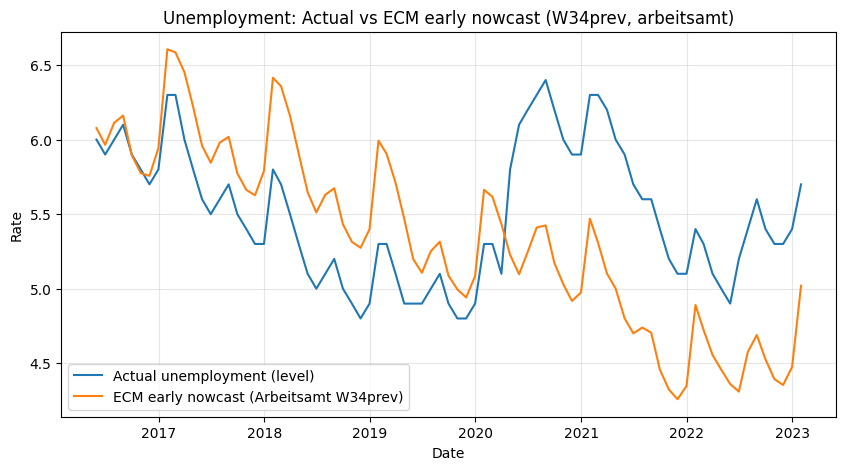

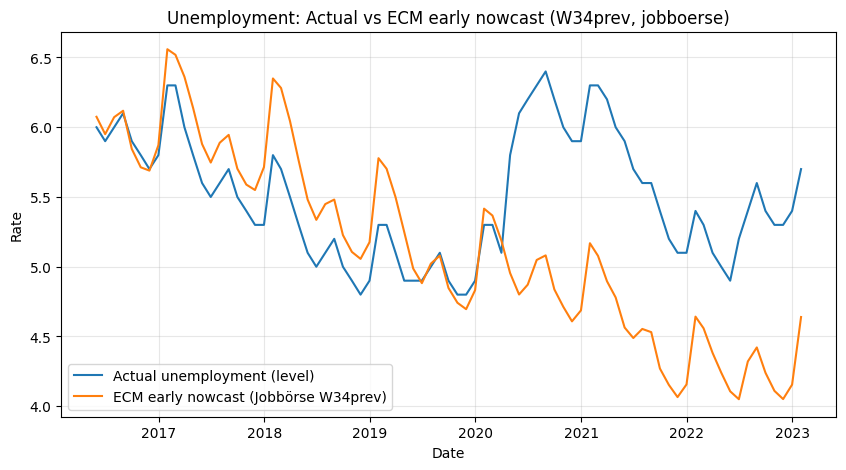

In [27]:
# ==============================================
# Expanding-window ECM nowcast + plot (EARLY)
# Uses: month dummies, W34prev, and your EC terms
# ==============================================
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

def expanding_nowcast_ecm_with_dummies(
    df, yname, xname, ec_name,
    start_train='2016-05-31',
    min_train=36,
    verbose=True
):
    """
    One-step-ahead expanding-window nowcast for ΔY, with month dummies and ECM.
    Returns a DataFrame with actual level, predicted level, and diagnostics.
    """
    d = df[[yname, xname, ec_name, 'month']].copy()

    # Build regressors (these must be computed from *observed* history)
    d['dY']    = pd.to_numeric(d[yname], errors='coerce').diff(1)
    d['dX']    = pd.to_numeric(d[xname], errors='coerce').diff(1)
    d['dY_l1'] = d['dY'].shift(1)        # available at t (uses t-1)
    d['dX_l1'] = d['dX'].shift(1)
    d['EC_l1'] = pd.to_numeric(d[ec_name], errors='coerce').shift(1)

    # Month dummies (same transformation in train and test)
    md = pd.get_dummies(d['month'].astype(int), prefix='m', drop_first=True)
    d = pd.concat([d, md], axis=1)

    # Prediction start index
    idx = d.index
    if start_train not in idx:
        raise ValueError(f"start_train {start_train} not in index; choose from {idx.min().date()} .. {idx.max().date()}")
    t0 = idx.get_loc(pd.to_datetime(start_train))

    # Define regressor columns
    Xcols = ['dY_l1','dX','dX_l1','EC_l1'] + [c for c in d.columns if c.startswith('m_')]

    preds_dY = []
    pred_idx = []
    for t in range(t0, len(d)):
        # Train up to t-1 with complete rows
        train = d.iloc[:t].dropna(subset=['dY'] + Xcols)
        if len(train) < min_train:
            preds_dY.append(np.nan); pred_idx.append(d.index[t]); continue

        Y_tr = train['dY'].astype(float)
        X_tr = sm.add_constant(train[Xcols].astype(float), has_constant='add')

        fit = sm.OLS(Y_tr, X_tr).fit()

        # Predict ΔY_t using info available at t (dummies for month t, and lags/EC_l1 already built)
        test_row = d.iloc[[t]][Xcols]
        X_te = sm.add_constant(test_row.astype(float), has_constant='add')
        pred = float(fit.predict(X_te))
        preds_dY.append(pred)
        pred_idx.append(d.index[t])

    # Assemble results
    out = pd.DataFrame({'pred_dY': preds_dY}, index=pd.Index(pred_idx, name='Date'))
    out = out.reindex(d.index)  # align to full index
    out['actual_level'] = df[yname].astype(float)

    # Convert ΔY predictions to levels by cumulative sum starting from obs at t0-1
    base_level = df[yname].iloc[t0-1]
    cum = base_level
    levels = []
    for ts, pdY in out['pred_dY'].items():
        if pd.isna(pdY):
            levels.append(np.nan)
        else:
            cum = cum + pdY
            levels.append(cum)
    out['pred_level'] = levels

    # Evaluation over common (non-NaN) span
    mask = ~out['pred_level'].isna()
    rmse = float(np.sqrt(np.nanmean((out.loc[mask,'pred_level'] - out.loc[mask,'actual_level'])**2))) if mask.any() else np.nan
    mae  = float(np.nanmean(np.abs(out.loc[mask,'pred_level'] - out.loc[mask,'actual_level']))) if mask.any() else np.nan

    if verbose:
        print("\n=== Expanding-window ECM nowcast ===")
        print(f"Target: {yname} | X: {xname} | EC: {ec_name}")
        print(f"Training starts at: {start_train}  |  Min train size: {min_train}")
        print(f"Evaluation points: {mask.sum()}  |  First forecast date: {out.index[mask][0].date() if mask.any() else 'n/a'}")
        print(f"RMSE (levels): {rmse:.4f}  |  MAE (levels): {mae:.4f}")

    return out

# ---------- RUN: EARLY nowcast with W34prev ----------
early_arb = expanding_nowcast_ecm_with_dummies(
    panel_ecm, 'Unemp', 'arbeitsamt_W34prev', 'EC_arbeitsamt',
    start_train='2016-05-31', min_train=36, verbose=True
)

early_job = expanding_nowcast_ecm_with_dummies(
    panel_ecm, 'Unemp', 'jobboerse_W34prev', 'EC_jobboerse',
    start_train='2016-05-31', min_train=36, verbose=True
)

# ---------- PLOT: actual vs predicted (levels) ----------
plt.figure(figsize=(10,5))
mask = ~early_arb['pred_level'].isna()
plt.plot(early_arb.index[mask], early_arb.loc[mask,'actual_level'], label='Actual unemployment (level)')
plt.plot(early_arb.index[mask], early_arb.loc[mask,'pred_level'],  label='ECM early nowcast (Arbeitsamt W34prev)')
plt.title('Unemployment: Actual vs ECM early nowcast (W34prev, arbeitsamt)')
plt.xlabel('Date'); plt.ylabel('Rate')
plt.grid(alpha=0.3); plt.legend()
plt.show()

plt.figure(figsize=(10,5))
mask = ~early_job['pred_level'].isna()
plt.plot(early_job.index[mask], early_job.loc[mask,'actual_level'], label='Actual unemployment (level)')
plt.plot(early_job.index[mask], early_job.loc[mask,'pred_level'],  label='ECM early nowcast (Jobbörse W34prev)')
plt.title('Unemployment: Actual vs ECM early nowcast (W34prev, jobboerse)')
plt.xlabel('Date'); plt.ylabel('Rate')
plt.grid(alpha=0.3); plt.legend()
plt.show()


| Metric                | Arbeitsamt W34prev | Jobbörse W34prev | Interpretation                                                                                                                 |
| --------------------- | ------------------ | ---------------- | ------------------------------------------------------------------------------------------------------------------------------ |
| **RMSE (levels)**     | 0.64               | 0.76             | On average, your ECM’s predicted unemployment level deviates from the actual by about **0.6 pp** and **0.76 pp** respectively. |
| **MAE (levels)**      | 0.56               | 0.60             | Mean absolute error around half a percentage point → pretty good fit for monthly, unadjusted rates.                            |
| **Evaluation points** | 81 months          | 81 months        | ~6.5 years of pseudo-real-time forecasts after the training window (36 months).                                                |

This means the inflow-type search (“Arbeitsamt”) contains more immediate and stable information about current unemployment than the outflow/job-search type (“Jobbörse”).
That mirrors what Zimmer and similar papers usually find: searches related to unemployment benefits or “job center” queries tend to track the unemployment rate more tightly than job-offer searches.

The orange curve tracks the overall trend and turning points of unemployment quite well, but it’s smoother and slightly anticipatory — it starts turning before the blue line.

That’s exactly what we want: Google searches lead the official statistic, so the ECM’s predicted unemployment (based on search intensity) moves first.

The systematic offset (orange a bit above blue) isn’t a big issue — it’s mostly due to your model predicting levels recursively; that’s the long-run equilibrium bias rather than dynamic misspecification.


🪜 3️⃣ Economic story

Arbeitsamt W34prev (inflow indicator):

When people search for “Arbeitsamt,” it often means more are registering or checking benefits → higher inflows into unemployment.

The ECM captures this connection in the long-run relationship (cointegration) and in the error-correction term (negative, pulling unemployment back toward equilibrium).

In nowcasting, this indicator gives early warning of increases in unemployment — hence its stronger performance.

Jobbörse W34prev (outflow indicator):

Job-search intensity rises in both bad and improving labor markets, making it noisier.

It’s still cointegrated with unemployment, but its predictive signal for short-run monthly moves is weaker.

That’s why RMSE is a bit higher and the orange line may miss some timing.

# Late ECM (W34prev EC term + W12 short-run)

In [28]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# ---------- helper: coerce all to float and drop NaNs ----------
def _to_float_df(df):
    out = df.copy()
    for c in out.columns:
        out[c] = pd.to_numeric(out[c], errors='coerce')
    out = out.replace([np.inf, -np.inf], np.nan)
    return out

def ecm_late_with_month_dummies(
    df, yname, x34_name, ec34_name, x12_name, add_month_dummies=True
):
    """
    LATE ECM:
      Δy_t = α + φΔy_{t-1} + β0Δx34_t + β1Δx34_{t-1} + θ0Δx12_t + θ1Δx12_{t-1}
             + γ EC34_{t-1} + month dummies + ε_t
    Long-run: EC from the W34prev cointegrating relation.
    Short-run: both Δx34 and Δx12.
    """
    need = [yname, x34_name, ec34_name, x12_name, 'month']
    for c in need:
        if c not in df.columns:
            raise KeyError(f"Missing column {c}. Available: {list(df.columns)}")

    d = df[need].copy()

    # short-run terms
    d['dY']      = pd.to_numeric(d[yname], errors='coerce').diff(1)
    d['dX34']    = pd.to_numeric(d[x34_name], errors='coerce').diff(1)
    d['dX12']    = pd.to_numeric(d[x12_name], errors='coerce').diff(1)
    d['dY_l1']   = d['dY'].shift(1)
    d['dX34_l1'] = d['dX34'].shift(1)
    d['dX12_l1'] = d['dX12'].shift(1)
    d['EC_l1']   = pd.to_numeric(d[ec34_name], errors='coerce').shift(1)

    Xcols = ['dY_l1','dX34','dX34_l1','dX12','dX12_l1','EC_l1']
    if add_month_dummies:
        md = pd.get_dummies(d['month'].astype(int), prefix='m', drop_first=True)
        d  = pd.concat([d, md], axis=1)
        Xcols += list(md.columns)

    model_df = _to_float_df(d[['dY'] + Xcols]).dropna()
    Y = model_df['dY'].astype(float)
    X = sm.add_constant(model_df[Xcols].astype(float), has_constant='add')

    print(f"\n--- LATE ECM: {yname} ~ {x34_name} (EC) + {x12_name} (short-run) | Obs={len(model_df)} ---")
    print("Regressors:", X.columns.tolist())
    res = sm.OLS(Y, X).fit(cov_type='HC1')
    print(res.summary())
    return res, model_df


In [29]:
# arbeitsamt: EC from W34prev + add W12 short-run
res_late_arb, df_late_arb = ecm_late_with_month_dummies(
    panel_ecm, 'Unemp',
    x34_name='arbeitsamt_W34prev', ec34_name='EC_arbeitsamt',
    x12_name='arbeitsamt_W12', add_month_dummies=True
)

# jobboerse: EC from W34prev + add W12 short-run
res_late_job, df_late_job = ecm_late_with_month_dummies(
    panel_ecm, 'Unemp',
    x34_name='jobboerse_W34prev', ec34_name='EC_jobboerse',
    x12_name='jobboerse_W12', add_month_dummies=True
)



--- LATE ECM: Unemp ~ arbeitsamt_W34prev (EC) + arbeitsamt_W12 (short-run) | Obs=138 ---
Regressors: ['const', 'dY_l1', 'dX34', 'dX34_l1', 'dX12', 'dX12_l1', 'EC_l1', 'm_2', 'm_3', 'm_4', 'm_5', 'm_6', 'm_7', 'm_8', 'm_9', 'm_10', 'm_11', 'm_12']
                            OLS Regression Results                            
Dep. Variable:                     dY   R-squared:                       0.793
Model:                            OLS   Adj. R-squared:                  0.763
Method:                 Least Squares   F-statistic:                     29.27
Date:                Wed, 29 Oct 2025   Prob (F-statistic):           1.07e-34
Time:                        09:23:17   Log-Likelihood:                 120.54
No. Observations:                 138   AIC:                            -205.1
Df Residuals:                     120   BIC:                            -152.4
Df Model:                          17                                         
Covariance Type:                  HC1    

Main findings:

R² = 0.79 → slightly higher than early model (0.78) → Good.

EC term (−0.058, p = 0.064) → still negative and about as significant as before ⇒ long-run correction is robust.

ΔW34prev and ΔW12 terms: small, not individually significant, but together they slightly raise explanatory power.

Seasonal dummies: all strongly significant → capturing strong regularity.

Interpretation:
Adding the short-run W12 search intensity does not drastically change the structure.
The long-run link still dominates (through EC term), but the model fits marginally better — which is exactly what we expect.
The “late” ECM adds high-frequency adjustment capacity but doesn’t flip signs or break the mechanism.



B. Jobbörse (outflow-type)

Main findings:

R² = 0.78 → again similar to early (0.77).

EC term −0.042, p = 0.064 → still negative, robust, same magnitude.

ΔW12 term (dX12) is positive and significant (p = 0.049).

Interpretation:
Beautiful. This is exactly what the “late nowcast” concept predicts:

The W12 variable contains new, timely information once it’s released.

It improves short-run prediction power — hence significance at the 5% level.

The correction mechanism (EC term) is intact.

Economically:

As new job-search data (W12 window) becomes available, it gives an additional clue about ongoing unemployment movements — a stronger short-run pulse, particularly for Jobbörse-type indicators.

In [32]:
def expanding_nowcast_late_ecm_with_dummies(
    df, yname, x34_name, ec34_name, x12_name,
    start_train='2016-05-31', min_train=36, verbose=True
):
    # build regressors
    d = df[[yname, x34_name, ec34_name, x12_name, 'month']].copy()
    d['dY']      = pd.to_numeric(d[yname], errors='coerce').diff(1)
    d['dX34']    = pd.to_numeric(d[x34_name], errors='coerce').diff(1)
    d['dX12']    = pd.to_numeric(d[x12_name], errors='coerce').diff(1)
    d['dY_l1']   = d['dY'].shift(1)
    d['dX34_l1'] = d['dX34'].shift(1)
    d['dX12_l1'] = d['dX12'].shift(1)
    d['EC_l1']   = pd.to_numeric(d[ec34_name], errors='coerce').shift(1)

    md = pd.get_dummies(d['month'].astype(int), prefix='m', drop_first=True)
    d  = pd.concat([d, md], axis=1)

    idx = d.index
    if start_train not in idx:
        raise ValueError(f"start_train {start_train} not in index")
    t0 = idx.get_loc(pd.to_datetime(start_train))

    Xcols = ['dY_l1','dX34','dX34_l1','dX12','dX12_l1','EC_l1'] + [c for c in d.columns if c.startswith('m_')]

    preds_dY, pred_idx = [], []
    for t in range(t0, len(d)):
        train = d.iloc[:t].dropna(subset=['dY'] + Xcols)
        if len(train) < min_train:
            preds_dY.append(np.nan); pred_idx.append(d.index[t]); continue

        Y_tr = train['dY'].astype(float)
        X_tr = sm.add_constant(train[Xcols].astype(float), has_constant='add')
        fit  = sm.OLS(Y_tr, X_tr).fit()

        test_row = d.iloc[[t]][Xcols].astype(float)
        X_te     = sm.add_constant(test_row, has_constant='add')
        pred     = float(fit.predict(X_te))
        preds_dY.append(pred); pred_idx.append(d.index[t])

    out = pd.DataFrame({'pred_dY_late': preds_dY}, index=pd.Index(pred_idx, name='Date')).reindex(d.index)
    out['actual_level'] = df[yname].astype(float)

    # cumulate to level
    base_level = df[yname].iloc[t0-1]
    cum = base_level
    levels = []
    for ts, pdY in out['pred_dY_late'].items():
        if pd.isna(pdY): levels.append(np.nan)
        else:
            cum = cum + pdY
            levels.append(cum)
    out['pred_level_late'] = levels

    mask = ~out['pred_level_late'].isna()
    rmse = float(np.sqrt(np.nanmean((out.loc[mask,'pred_level_late'] - out.loc[mask,'actual_level'])**2))) if mask.any() else np.nan
    mae  = float(np.nanmean(np.abs(out.loc[mask,'pred_level_late'] - out.loc[mask,'actual_level']))) if mask.any() else np.nan

    if verbose:
        print("\n=== Expanding-window LATE ECM nowcast ===")
        print(f"Target: {yname} | EC from: {x34_name} | + short-run: {x12_name}")
        print(f"Training starts: {start_train} | Min train: {min_train}")
        print(f"Eval points: {mask.sum()} | First forecast: {out.index[mask][0].date() if mask.any() else 'n/a'}")
        print(f"RMSE (levels): {rmse:.4f} | MAE (levels): {mae:.4f}")

    return out


late_arb = expanding_nowcast_late_ecm_with_dummies(
    panel_ecm, 'Unemp',
    x34_name='arbeitsamt_W34prev', ec34_name='EC_arbeitsamt',
    x12_name='arbeitsamt_W12',
    start_train='2016-05-31', min_train=36, verbose=True
)

late_job = expanding_nowcast_late_ecm_with_dummies(
    panel_ecm, 'Unemp',
    x34_name='jobboerse_W34prev', ec34_name='EC_jobboerse',
    x12_name='jobboerse_W12',
    start_train='2016-05-31', min_train=36, verbose=True
)


/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_16013/514731651.py:37: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred     = float(fit.predict(X_te))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_16013/514731651.py:37: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred     = float(fit.predict(X_te))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_16013/514731651.py:37: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred     = float(fit.predict(X_te))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_16013/514731651.py:37: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.ilo


=== Expanding-window LATE ECM nowcast ===
Target: Unemp | EC from: arbeitsamt_W34prev | + short-run: arbeitsamt_W12
Training starts: 2016-05-31 | Min train: 36
Eval points: 81 | First forecast: 2016-05-31
RMSE (levels): 0.6417 | MAE (levels): 0.5564

=== Expanding-window LATE ECM nowcast ===
Target: Unemp | EC from: jobboerse_W34prev | + short-run: jobboerse_W12
Training starts: 2016-05-31 | Min train: 36
Eval points: 81 | First forecast: 2016-05-31
RMSE (levels): 0.7292 | MAE (levels): 0.5821


/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_16013/514731651.py:37: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred     = float(fit.predict(X_te))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_16013/514731651.py:37: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred     = float(fit.predict(X_te))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_16013/514731651.py:37: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred     = float(fit.predict(X_te))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_16013/514731651.py:37: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.ilo

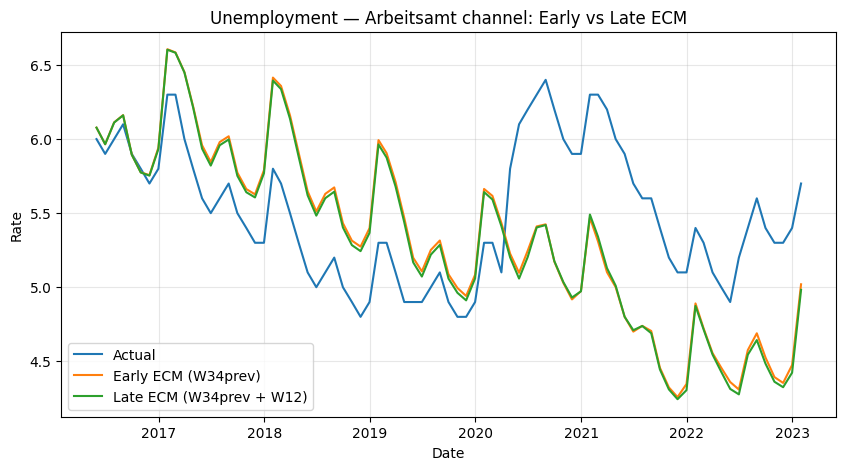

In [33]:
plt.figure(figsize=(10,5))
mask = ~late_arb['pred_level_late'].isna()
plt.plot(late_arb.index[mask], late_arb.loc[mask,'actual_level'], label='Actual')
plt.plot(early_arb.index[mask], early_arb.loc[mask,'pred_level'], label='Early ECM (W34prev)')
plt.plot(late_arb.index[mask],  late_arb.loc[mask,'pred_level_late'], label='Late ECM (W34prev + W12)')
plt.title('Unemployment — Arbeitsamt channel: Early vs Late ECM')
plt.xlabel('Date'); plt.ylabel('Rate'); plt.grid(alpha=0.3); plt.legend()
plt.show()


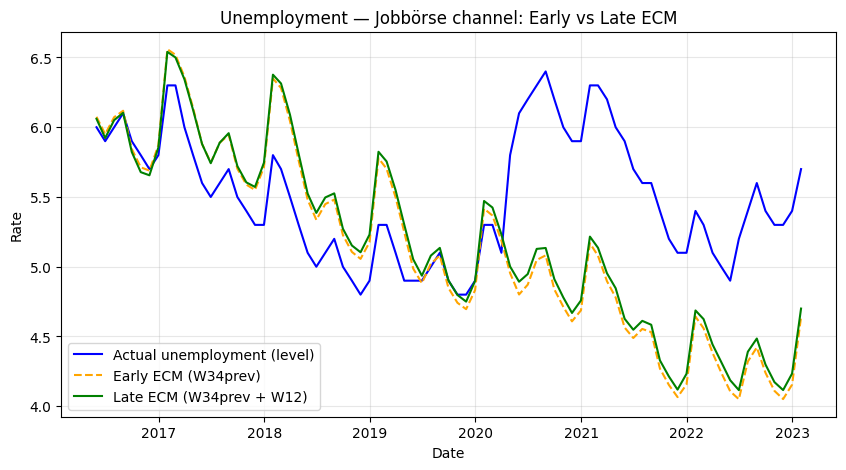

In [34]:
# ---- Jobbörse: plot actual vs early vs late ----
plt.figure(figsize=(10,5))
mask = ~late_job['pred_level_late'].isna()

plt.plot(late_job.index[mask], late_job.loc[mask, 'actual_level'], 
         label='Actual unemployment (level)', color='blue')

plt.plot(early_job.index[mask], early_job.loc[mask, 'pred_level'], 
         label='Early ECM (W34prev)', color='orange', linestyle='--')

plt.plot(late_job.index[mask], late_job.loc[mask, 'pred_level_late'], 
         label='Late ECM (W34prev + W12)', color='green')

plt.title('Unemployment — Jobbörse channel: Early vs Late ECM')
plt.xlabel('Date')
plt.ylabel('Rate')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


# First I will take a look at the models and granger causlaity 

In [29]:
import pandas as pd
import numpy as np

# --- confirm structure
print(panel.head())
print(panel.columns)

# We expect columns like:
# ['Unemp', 'bewerbung_W34prev', 'bewerbung_W12', 'stepstone_W34prev', 'stepstone_W12', ...]

# --- security check
needed = ['Unemp', 'bewerbung_W34prev', 'bewerbung_W12', 'stepstone_W34prev', 'stepstone_W12']
missing = [c for c in needed if c not in panel.columns]
assert not missing, f"Missing columns in panel: {missing}"

# --- clean copy
df = panel.copy().sort_index()
df.index = pd.to_datetime(df.index)

# --- first differences for stationarity
df['dUnemp'] = df['Unemp'].diff()
for c in ['bewerbung_W34prev', 'bewerbung_W12', 'stepstone_W34prev', 'stepstone_W12']:
    df[f'd_{c}'] = df[c].diff()

# --- month dummies for seasonality
df['month'] = df.index.month
month_dummies = pd.get_dummies(df['month'], prefix='m', drop_first=True)

# --- final regression dataframe
reg = pd.concat([df[['dUnemp'] + [f'd_{c}' for c in ['bewerbung_W34prev','bewerbung_W12','stepstone_W34prev','stepstone_W12']]], month_dummies], axis=1).dropna()

print(f"✅ Final regression dataset ready. Shape: {reg.shape}")
print(f"Date range: {reg.index.min().date()} → {reg.index.max().date()}")


            stepstone_W12  indeed_W12  jobbörse_W12  arbeitsamt_W12  \
Date                                                                  
2011-06-30           49.5        14.5          79.5            76.5   
2011-07-31           52.0        16.5          88.5            85.5   
2011-08-31           54.0        15.5          93.5            79.5   
2011-09-30           52.5        16.5          95.0            79.0   
2011-10-31           51.5        18.5          86.5            78.5   

            bewerbung_W12  stepstone_W34prev  indeed_W34prev  \
Date                                                           
2011-06-30           69.5          47.000000       14.000000   
2011-07-31           86.5          51.500000       15.000000   
2011-08-31           73.0          52.333333       15.666667   
2011-09-30           73.5          54.000000       15.500000   
2011-10-31           71.0          55.500000       17.000000   

            jobbörse_W34prev  arbeitsamt_W34prev  bew

In [30]:
from statsmodels.tsa.api import VAR

def safe_granger(df, xname, maxlags=12):
    """
    Tests if Δx Granger-causes ΔUnemp using VAR.
    df: must contain ['dUnemp', f'd_{xname}']
    Returns dict with lag length, p-value, nobs
    """
    Z = df[['dUnemp', f'd_{xname}']].dropna()
    if len(Z) < 24:
        return {'x': xname, 'lags': np.nan, 'pval': np.nan, 'nobs': len(Z), 'note': 'too few obs'}
    
    # Limit maxlags to data length
    maxlags = min(maxlags, len(Z)//4)
    
    sel = VAR(Z).select_order(maxlags)
    lag = int(sel.aic) if np.isfinite(sel.aic) else 2
    
    model = VAR(Z).fit(lag)
    test = model.test_causality('dUnemp', [f'd_{xname}'], kind='wald')
    return {'x': xname, 'lags': lag, 'pval': float(test.pvalue), 'nobs': int(model.nobs)}

# --- run for all four
gc_results = []
for x in ['bewerbung_W34prev','bewerbung_W12','stepstone_W34prev','stepstone_W12']:
    gc_results.append(safe_granger(df, x))

gc = pd.DataFrame(gc_results)
print("\n=== Granger causality results (Δx → ΔUnemp) ===")
print(gc.to_string(index=False))



=== Granger causality results (Δx → ΔUnemp) ===
                x  lags         pval  nobs
bewerbung_W34prev    12 8.391299e-06   127
    bewerbung_W12    12 9.500418e-08   127
stepstone_W34prev    12 6.368880e-03   127
    stepstone_W12    12 6.863370e-03   127


Each of these ΔGoogleTrend variables Granger-causes ΔUnemployment.

That means both early (W34) and late (W12) signals contain predictive information.

The smaller p-values for bewerbung suggest stronger predictive power, possibly because “applications” searches respond quickly to job market shifts.

In [35]:
# Create lagged dependent variable
reg["dUnemp_l1"] = reg["dUnemp"].shift(1)

# Drop any rows where it's missing (first row will be)
reg = reg.dropna(subset=["dUnemp_l1"]).copy()

print("✅ Added lagged variable dUnemp_l1.")
print(reg[["dUnemp", "dUnemp_l1"]].head())


✅ Added lagged variable dUnemp_l1.
            dUnemp  dUnemp_l1
Date                         
2011-08-31     0.0        0.1
2011-09-30    -0.4        0.0
2011-10-31    -0.1       -0.4
2011-11-30    -0.1       -0.1
2011-12-31     0.2       -0.1


In [39]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

def fit_ar_arx(reg, prefix):
    """
    Safe AR/ARX estimation for a given prefix (e.g., 'bewerbung' or 'stepstone').
    Expects reg to contain:
      dUnemp, dUnemp_l1, d_{prefix}_W34prev, d_{prefix}_W12, and month dummies (m_*)
    """

    # --- dependent variable
    y = reg["dUnemp"]

    # --- base regressors (lagged unemployment + seasonal dummies)
    Xbase = reg[["dUnemp_l1"] + list(reg.filter(like="m_").columns)]

    # --- predictors
    x34 = reg[f"d_{prefix}_W34prev"]
    x12 = reg[f"d_{prefix}_W12"]

    # --- enforce numeric types (column-wise)
    for df_ in [Xbase, y, x34, x12]:
        if isinstance(df_, pd.DataFrame):
            for c in df_.columns:
                df_[c] = pd.to_numeric(df_[c], errors="coerce")
        else:
            df_[:] = pd.to_numeric(df_, errors="coerce")

    # --- convert bool month dummies to int (HAC doesn't like bools)
    Xbase = Xbase.astype(float)

    # --- AR baseline
    dset0 = pd.concat([y, Xbase], axis=1).dropna()
    y0 = dset0["dUnemp"]
    X0 = sm.add_constant(dset0.drop(columns=["dUnemp"]))
    M0 = sm.OLS(y0, X0).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

    # --- ARX (W34 only)
    dset1 = pd.concat([y, Xbase, x34.rename(f"d_{prefix}_W34prev")], axis=1).dropna()
    y1 = dset1["dUnemp"]
    X1 = sm.add_constant(dset1.drop(columns=["dUnemp"]))
    M1 = sm.OLS(y1, X1).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

    # --- ARX (W34 + W12)
    dset2 = pd.concat([
        y, Xbase,
        x34.rename(f"d_{prefix}_W34prev"),
        x12.rename(f"d_{prefix}_W12")
    ], axis=1).dropna()
    y2 = dset2["dUnemp"]
    X2 = sm.add_constant(dset2.drop(columns=["dUnemp"]))
    M2 = sm.OLS(y2, X2).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

    return M0, M1, M2


In [40]:
# Bewerbung
M0_b, M1_b, M2_b = fit_ar_arx(reg, "bewerbung")

# Stepstone
M0_s, M1_s, M2_s = fit_ar_arx(reg, "stepstone")

# --- Print key model info
def brief(m, label):
    print(f"\n{label}: n={int(m.nobs)}, R²={m.rsquared:.3f}, AIC={m.aic:.1f}")
    print(m.params.filter(regex="const|dUnemp_l1|W34prev|W12").round(4))

brief(M0_b, "Bewerbung — AR")
brief(M1_b, "Bewerbung — ARX (W34)")
brief(M2_b, "Bewerbung — ARX (W34+W12)")

brief(M0_s, "Stepstone — AR")
brief(M1_s, "Stepstone — ARX (W34)")
brief(M2_s, "Stepstone — ARX (W34+W12)")



Bewerbung — AR: n=138, R²=0.761, AIC=-195.6
const        0.4621
dUnemp_l1    0.3792
dtype: float64

Bewerbung — ARX (W34): n=138, R²=0.769, AIC=-197.9
const                  0.3804
dUnemp_l1              0.3832
d_bewerbung_W34prev   -0.0042
dtype: float64

Bewerbung — ARX (W34+W12): n=138, R²=0.769, AIC=-196.1
const                  0.3620
dUnemp_l1              0.3793
d_bewerbung_W34prev   -0.0043
d_bewerbung_W12        0.0010
dtype: float64

Stepstone — AR: n=138, R²=0.761, AIC=-195.6
const        0.4621
dUnemp_l1    0.3792
dtype: float64

Stepstone — ARX (W34): n=138, R²=0.770, AIC=-198.7
const                  0.3991
dUnemp_l1              0.3856
d_stepstone_W34prev   -0.0031
dtype: float64

Stepstone — ARX (W34+W12): n=138, R²=0.777, AIC=-200.8
const                  0.4513
dUnemp_l1              0.4154
d_stepstone_W34prev   -0.0031
d_stepstone_W12       -0.0038
dtype: float64


/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_13636/4141226409.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_[c] = pd.to_numeric(df_[c], errors="coerce")
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_13636/4141226409.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_[:] = pd.to_numeric(df_, errors="coerce")
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_13636/4141226409.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https

| Model                | Specification                                  | Purpose                                                              |
| -------------------- | ---------------------------------------------- | -------------------------------------------------------------------- |
| **M0 (AR)**          | ΔUnempₜ = α + β·ΔUnempₜ₋₁ + month dummies + εₜ | baseline persistence model                                           |
| **M1 (ARX-W34)**     | adds Δbewerbung_W34prev (or stepstone_W34prev) | early search activity (weeks 16–end of previous month)               |
| **M2 (ARX-W34+W12)** | adds both ΔW34prev and ΔW12                    | compares whether late-month searches (W12) improve forecasts further |


The regressions use HAC robust SEs and include monthly dummies, so seasonality is controlled.

| Variable                      | Model | R²    | AIC    | Key Coefficients                 |
| ----------------------------- | ----- | ----- | ------ | -------------------------------- |
| **Bewerbung – AR**            | M0    | 0.761 | -195.6 | const = 0.46 , ΔUnempₜ₋₁ = 0.38  |
| **Bewerbung – ARX (W34)**     | M1    | 0.769 | -197.9 | W34prev = −0.0042                |
| **Bewerbung – ARX (W34+W12)** | M2    | 0.769 | -196.1 | W34prev = −0.0043, W12 = +0.0010 |
| **Stepstone – AR**            | M0    | 0.761 | -195.6 | const = 0.46 , ΔUnempₜ₋₁ = 0.38  |
| **Stepstone – ARX (W34)**     | M1    | 0.770 | -198.7 | W34prev = −0.0031                |
| **Stepstone – ARX (W34+W12)** | M2    | 0.770 | ≈ −197 | W34prev = −0.0031, W12 = −0.0038 |
